In [28]:
import sys, importlib
import tcrempnet_utils as utils
importlib.reload(utils)
print('utils loaded; available:', len([n for n in dir(utils) if callable(getattr(utils, n, None))]))


utils loaded; available: 51


In [2]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA

### Load metadata

In [3]:
# Path from your message
METADATA_PATH = "/projects/immunestatus/emerson_hla/airr_format/metadata.tsv"

# Expected columns (per your snippet): sample_id, age, race, sex, cmv, hla, allele
meta = pd.read_csv(METADATA_PATH, sep="\t").fillna("")
# Keep only required columns
expected_cols = ["sample_id", "age", "race", "sex", "cmv", "hla", "allele"]
meta = meta[[c for c in expected_cols if c in meta.columns]].copy()
print(meta.shape)
meta.head()


(25, 7)


,sample_id,age,race,sex,cmv,hla,allele
0,HIP08345,,,male,-,"HLA-A*01,HLA-A*26,HLA-B*08,HLA-B*38",HLA-A*01
1,HIP13178,21.0,"caucasian,non-hispanic or latino",female,-,"HLA-A*01,HLA-B*14,HLA-B*37",HLA-A*01
2,HIP13859,51.0,"caucasian,non-hispanic or latino",male,-,"HLA-A*01,HLA-A*26,HLA-B*38,HLA-B*57",HLA-A*01
3,HIP13794,36.0,"caucasian,non-hispanic or latino",female,-,"HLA-A*01,HLA-A*32,HLA-B*57,HLA-B*62",HLA-A*01
4,HIP03004,42.0,,female,-,"HLA-A*01,HLA-A*25,HLA-B*08,HLA-B*44",HLA-A*01


In [4]:
meta = meta[meta.sample_id != 'HIP12143'].reset_index(drop=True)

### Group samples into 5-sample sets by the `allele` column

In [5]:
# Group samples based on the last column `allele` (as per your snippet)
allele_to_samples = (meta.groupby("allele")["sample_id"]
                        .apply(list)
                        .to_dict())

# Show summary
{allele: len(s) for allele, s in allele_to_samples.items()}


{'HLA-A*01': 5, 'HLA-A*02': 5, 'HLA-A*03': 5, 'HLA-A*11': 4, 'HLA-A*24': 5}

In [6]:
# список всех образцов (например, из метадаты или заранее)
samples = meta["sample_id"].tolist()

# создаём словарь: sample_name -> (summary, c15)
sample_to_info = {}
for s in samples:
    summary, c15 = utils.get_sample_info(s, airr_path=f'/projects/immunestatus/emerson_hla/airr_format',
                                         tcrempnet_path = f'/projects/immunestatus/emerson_hla/tcrempnet')
    sample_to_info[s] = (summary, c15)

# теперь sample_to_info["HIP08345"] даст кортеж (summary_df, число_клонов)



    sample: HIP08345
    clusters: 41966
    overall from sample: 236090
    

    sample: HIP13178
    clusters: 39533
    overall from sample: 159779
    

    sample: HIP13859
    clusters: 38736
    overall from sample: 131723
    

    sample: HIP13794
    clusters: 40546
    overall from sample: 182207
    

    sample: HIP03004
    clusters: 42120
    overall from sample: 245613
    

    sample: HIP12538
    clusters: 42172
    overall from sample: 248084
    

    sample: HIP14018
    clusters: 41235
    overall from sample: 236866
    

    sample: HIP09159
    clusters: 37438
    overall from sample: 102842
    

    sample: HIP08230
    clusters: 39782
    overall from sample: 189059
    

    sample: HIP10564
    clusters: 40966
    overall from sample: 226810
    

    sample: HIP14074
    clusters: 42357
    overall from sample: 298449
    

    sample: HIP14209
    clusters: 37068
    overall from sample: 129254
    

    sample: HIP00825
    clusters: 42430
    overal

In [7]:
sample_to_clonotypes = {}
for s in samples:
    sample_to_clonotypes[s] = utils.get_clonotypes(s, data_path='/projects/immunestatus/emerson_hla')

In [8]:
utils.get_clonotypes(samples[0], data_path='/projects/immunestatus/emerson_hla')

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,pgen
0,s_0,16553,CASSVDSTGANVLTF,TRBV6-1*01,TRBJ2-6*01,sample,0.000013,4.665092e-09
1,s_210040,16553,CASSVESTGANVLNV,TRBV6-1*01,TRBJ2-6*01,sample,0.000013,0.000000e+00
2,b_198560,16553,CASSVDSSGANVLTF,TRBV6-1*01,TRBJ2-6*01,background,0.000013,5.795866e-08
3,s_4,0,CSARDPERGDTDTQYF,TRBV20-1*01,TRBJ2-3*01,sample,0.000013,1.021204e-10
4,s_111200,0,CSARDPERGDTDTKYL,TRBV20-1*01,TRBJ2-3*01,sample,0.000013,0.000000e+00
...,...,...,...,...,...,...,...,...
12344,s_231607,17391,CAAQGPSYEQYF,TRBV27*01,TRBJ2-7*01,sample,0.000013,3.798121e-09
12345,b_961301,17391,CASTGPSYEQYF,TRBV27*01,TRBJ2-7*01,background,0.000013,3.114460e-07
12346,s_232416,17421,CASSYSGFQETQYV,TRBV6-6*01,TRBJ2-5*01,sample,0.000013,4.041198e-17
12347,s_232417,17421,CASSYSGFQETQYF,TRBV6-6*01,TRBJ2-5*01,sample,0.000013,1.703326e-08


### Helper to load clonotypes for a set of samples

In [9]:
def load_group_clonotypes(samples):
    all_clonotypes = []
    for sample in samples:
        t = utils.get_clonotypes(sample, data_path='/projects/immunestatus/emerson_hla')
        # Mirror your prior pattern: drop p-value column if present; keep minimal transformations
        if "enrichment_pvalue_zbinom" in t.columns:
            t = t.drop(columns=["enrichment_pvalue_zbinom"])
        # Rename/augment IDs to keep them sample-unique (same as in your notebook)
        if "cluster_id" in t.columns:
            t = t.copy()
            t["cluster_id"] = sample + "_c" + t["cluster_id"].astype(str)
        # Ensure sample_name exists
        t["sample_name"] = sample
        all_clonotypes.append(t)
    return pd.concat(all_clonotypes, ignore_index=True)


### Merge clusters within each allele and keep only public clusters

In [10]:
allele_results = {}

for allele, samples in allele_to_samples.items():
    if len(samples) == 0:
        continue

    # 2. Read data (for all samples of this allele)
    df = load_group_clonotypes(samples)

    # 3. Merge clusters by shared CDR3 across the group
    #    Using the same function you use in your previous notebook
    df_merged, mapping = utils.merge_clusters_by_shared_cdr3(df)

    # 4. Keep only clusters public within the allele: merged_cluster_id seen in >1 unique sample_name
    public_ids = (df_merged.groupby("merged_cluster_id")["sample_name"]
                           .nunique()
                           .reset_index(name="sample_count"))
    public_ids = public_ids[public_ids["sample_count"] > 1]["merged_cluster_id"]

    df_public = df_merged[df_merged["merged_cluster_id"].isin(public_ids)].copy()

    allele_results[allele] = {
        "all": df,
        "merged": df_merged,
        "public": df_public,
        "mapping": mapping
    }

# Quick sanity: sizes per allele
{allele: {k: (v[k].shape if hasattr(v[k], 'shape') else 'mapping') for k in v} for allele, v in allele_results.items()}


{'HLA-A*01': {'all': (55516, 8),
  'merged': (55516, 9),
  'public': (20996, 9),
  'mapping': 'mapping'},
 'HLA-A*02': {'all': (59206, 8),
  'merged': (59206, 9),
  'public': (22068, 9),
  'mapping': 'mapping'},
 'HLA-A*03': {'all': (57015, 8),
  'merged': (57015, 9),
  'public': (23634, 9),
  'mapping': 'mapping'},
 'HLA-A*11': {'all': (50625, 8),
  'merged': (50625, 9),
  'public': (16012, 9),
  'mapping': 'mapping'},
 'HLA-A*24': {'all': (60455, 8),
  'merged': (60455, 9),
  'public': (25257, 9),
  'mapping': 'mapping'}}

### Peek at one allele's public clusters

In [11]:
# Choose the first allele to peek at (if any)
first_allele = next(iter(allele_results)) if len(allele_results) else None
first_allele, (allele_results[first_allele]["public"].head() if first_allele else None)


('HLA-A*01',
    clone_id    cluster_id    cdr3aa_beta       v_beta      j_beta  source  \
 84    s_225  HIP08345_c43  CASSLGSGTEAFF  TRBV11-3*01  TRBJ1-1*01  sample   
 85  s_11889  HIP08345_c43  CASSLGTGTEAFF  TRBV11-3*01  TRBJ1-1*01  sample   
 86  s_18052  HIP08345_c43  CASSVGQGTEAFF  TRBV11-3*01  TRBJ1-1*01  sample   
 87  s_71284  HIP08345_c43  CASSLGAGTEAFF  TRBV11-3*01  TRBJ1-1*01  sample   
 88  s_79345  HIP08345_c43  CASSLGTGREAFF  TRBV11-3*01  TRBJ1-1*01  sample   
 
             pgen sample_name  merged_cluster_id  
 84  1.644859e-07    HIP08345                 18  
 85  7.315101e-07    HIP08345                 18  
 86  3.120442e-07    HIP08345                 18  
 87  3.008322e-07    HIP08345                 18  
 88  5.706245e-08    HIP08345                 18  )

In [12]:
t = allele_results['HLA-A*01']['public']
t

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,pgen,sample_name,merged_cluster_id
84,s_225,HIP08345_c43,CASSLGSGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,1.644859e-07,HIP08345,18
85,s_11889,HIP08345_c43,CASSLGTGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,7.315101e-07,HIP08345,18
86,s_18052,HIP08345_c43,CASSVGQGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,3.120442e-07,HIP08345,18
87,s_71284,HIP08345_c43,CASSLGAGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,3.008322e-07,HIP08345,18
88,s_79345,HIP08345_c43,CASSLGTGREAFF,TRBV11-3*01,TRBJ1-1*01,sample,5.706245e-08,HIP08345,18
...,...,...,...,...,...,...,...,...,...
55511,b_1159563,HIP03004_c21792,CAWSSGYNQPQHF,TRBV30*01,TRBJ1-5*01,background,1.543328e-09,HIP03004,6094
55512,b_1161283,HIP03004_c21792,CAWSAGSNQPQHF,TRBV30*01,TRBJ1-5*01,background,2.935810e-08,HIP03004,6094
55513,b_1207010,HIP03004_c21792,CAWSTGNNQPQHF,TRBV30*01,TRBJ1-5*01,background,2.907573e-09,HIP03004,6094
55514,b_1229951,HIP03004_c21792,CAWSRGDNQPQHF,TRBV30*01,TRBJ1-5*01,background,1.028349e-08,HIP03004,6094


In [13]:
t[t.merged_cluster_id == 18]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,pgen,sample_name,merged_cluster_id
84,s_225,HIP08345_c43,CASSLGSGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,1.644859e-07,HIP08345,18
85,s_11889,HIP08345_c43,CASSLGTGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,7.315101e-07,HIP08345,18
86,s_18052,HIP08345_c43,CASSVGQGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,3.120442e-07,HIP08345,18
87,s_71284,HIP08345_c43,CASSLGAGTEAFF,TRBV11-3*01,TRBJ1-1*01,sample,3.008322e-07,HIP08345,18
88,s_79345,HIP08345_c43,CASSLGTGREAFF,TRBV11-3*01,TRBJ1-1*01,sample,5.706245e-08,HIP08345,18
...,...,...,...,...,...,...,...,...,...
44857,s_10440,HIP03004_c1410,CASSLGVGTEAFF,TRBV7-6*01,TRBJ1-1*01,sample,1.429205e-07,HIP03004,18
44858,s_29990,HIP03004_c1410,CASSLGVGTEAFF,TRBV7-6*01,TRBJ1-1*01,sample,1.429205e-07,HIP03004,18
44859,s_48125,HIP03004_c1410,CASSLGVGTEAFF,TRBV7-6*01,TRBJ1-1*01,sample,1.429205e-07,HIP03004,18
44860,b_598599,HIP03004_c1410,CASSLGLGTEAFF,TRBV7-6*01,TRBJ1-1*01,background,1.678964e-07,HIP03004,18


In [14]:
vdjdb = pd.read_csv('cluster_members.txt', sep='\t')

In [15]:
vdjdb

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
0,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLSGDDYNEQFF,102.447143,32.107434,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
1,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDDYNEQFF,36.799698,2.795705,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
2,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDNYNEQFF,3.568838,-52.141266,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
3,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDSYNEQFF,-36.541775,-2.006452,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
4,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLVGDSYNEQFF,-105.450820,18.494963,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35563,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CAASENYNQGKLIF,308.410316,128.603566,M.A.TVYGFCLL.2,12,"TRAV7-4*01,TRAV7D-4*01",TRAJ23*01,5,5,TRAV12D-1*01,TRAJ23*01
35564,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIMNYNQGKLIF,187.064152,-192.603423,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35565,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIPNYNQGKLIF,267.595691,-180.697136,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35566,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALRENYNQGKLIF,242.143769,-43.271264,M.A.TVYGFCLL.2,12,TRAV12-3*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01


In [16]:
ebv_vdjdb = vdjdb[(vdjdb['antigen.species'] == 'EBV') & (vdjdb.gene == 'TRB')]
ebv_vdjdb

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
50,HomoSapiens,AVFDRKSDAK,EBNA3B,EBV,HLA-A*11:01,B2M,MHCI,TRB,CASSVTSATGELFF,631.359443,97.958253,H.B.AVFDRKSDAK.11,8,TRBV28*01,TRBJ2-2*01,4,8,TRBV28*01,TRBJ2-2*01
51,HomoSapiens,AVFDRKSDAK,EBNA3B,EBV,HLA-A*11:01,B2M,MHCI,TRB,CASSWSYEQYF,138.273388,-163.643866,H.B.AVFDRKSDAK.5,5,TRBV6-3*01,TRBJ2-7*01,4,5,TRBV6-3*01,TRBJ2-7*01
52,HomoSapiens,AVFDRKSDAK,EBNA3B,EBV,HLA-A*11:01,B2M,MHCI,TRB,CASSYGYEQYF,146.193149,-23.973978,H.B.AVFDRKSDAK.5,5,TRBV19*01,TRBJ2-7*01,4,6,TRBV6-3*01,TRBJ2-7*01
53,HomoSapiens,AVFDRKSDAK,EBNA3B,EBV,HLA-A*11:01,B2M,MHCI,TRB,CASSYSYEQYF,157.471857,-99.857884,H.B.AVFDRKSDAK.5,5,TRBV6-5*01,TRBJ2-7*01,5,5,TRBV6-3*01,TRBJ2-7*01
81,HomoSapiens,AVFDRKSDAK,EBNA3B,EBV,HLA-A*11:01,B2M,MHCI,TRB,CASSFSYEQYF,196.089794,-153.848467,H.B.AVFDRKSDAK.5,5,TRBV6-3*01,TRBJ2-7*01,4,5,TRBV6-3*01,TRBJ2-7*01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34345,HomoSapiens,YVLDHLIVV,BRLF1,EBV,HLA-A*02:01,B2M,MHCI,TRB,CASSPHLGAAAEQYF,90.498679,-692.335002,H.B.YVLDHLIVV.6,5,TRBV19*01,TRBJ2-7*01,4,11,TRBV19*01,TRBJ2-7*01
34346,HomoSapiens,YVLDHLIVV,BRLF1,EBV,HLA-A*02:01,B2M,MHCI,TRB,CASSPHLGVAAEQYF,161.660302,-668.975452,H.B.YVLDHLIVV.6,5,TRBV19*01,TRBJ2-7*01,4,11,TRBV19*01,TRBJ2-7*01
34347,HomoSapiens,YVLDHLIVV,BRLF1,EBV,HLA-A*02:01,B2M,MHCI,TRB,CASSPHSGAAAEQYF,113.194982,-763.151739,H.B.YVLDHLIVV.6,5,TRBV19*01,TRBJ2-7*01,4,11,TRBV19*01,TRBJ2-7*01
34348,HomoSapiens,YVLDHLIVV,BRLF1,EBV,HLA-A*02:01,B2M,MHCI,TRB,CASSPLLGSNQPQHF,-671.692599,-294.340903,H.B.YVLDHLIVV.3,6,TRBV19*01,TRBJ1-5*01,4,8,TRBV19*01,TRBJ1-5*01


In [17]:
ebv_vdjdb['mhc.a'].value_counts()

mhc.a
HLA-A*02:01    272
HLA-B*08:01    113
HLA-A*11:01     18
HLA-B*35:01     15
HLA-B*07:02      7
Name: count, dtype: int64

In [18]:
allele_to_vdjdb_subset = {}
for allele in allele_to_samples.keys():
    clonotypes = set(ebv_vdjdb[ebv_vdjdb['mhc.a'].apply(lambda x: x.startswith(allele))].cdr3aa)
    clonotypes = [ClonotypeAA(cdr3aa=x) for x in clonotypes]
    allele_to_vdjdb_subset[allele] = ClonotypeDataset(clonotypes)

In [19]:
allele_to_vdjdb_subset

{'HLA-A*01': A dataset of 0 clonotypes and 0 clusters,
 'HLA-A*02': A dataset of 272 clonotypes and 22 clusters,
 'HLA-A*03': A dataset of 0 clonotypes and 0 clusters,
 'HLA-A*11': A dataset of 18 clonotypes and 3 clusters,
 'HLA-A*24': A dataset of 0 clonotypes and 0 clusters}

In [20]:
all_rows = []
for sample, (summary, c15) in sample_to_info.items():
    df = summary.copy()
    df["cluster_name"] = df.apply(lambda x: f"{sample}_c{int(x['cluster_id'])}", axis=1)
    df["sample_name"] = sample
    all_rows.append(df[["cluster_name", "enrichment_pvalue_zbinom", "log_fold_change"]])

all_clusters_df = pd.concat(all_rows, ignore_index=True)

all_clusters_df.head()


,cluster_name,enrichment_pvalue_zbinom,log_fold_change
0,HIP08345_c0,0.000013,1.056830
1,HIP08345_c1,0.000002,0.880738
2,HIP08345_c2,0.273233,0.454770
3,HIP08345_c3,0.614789,0.153740
4,HIP08345_c4,0.615213,0.082384


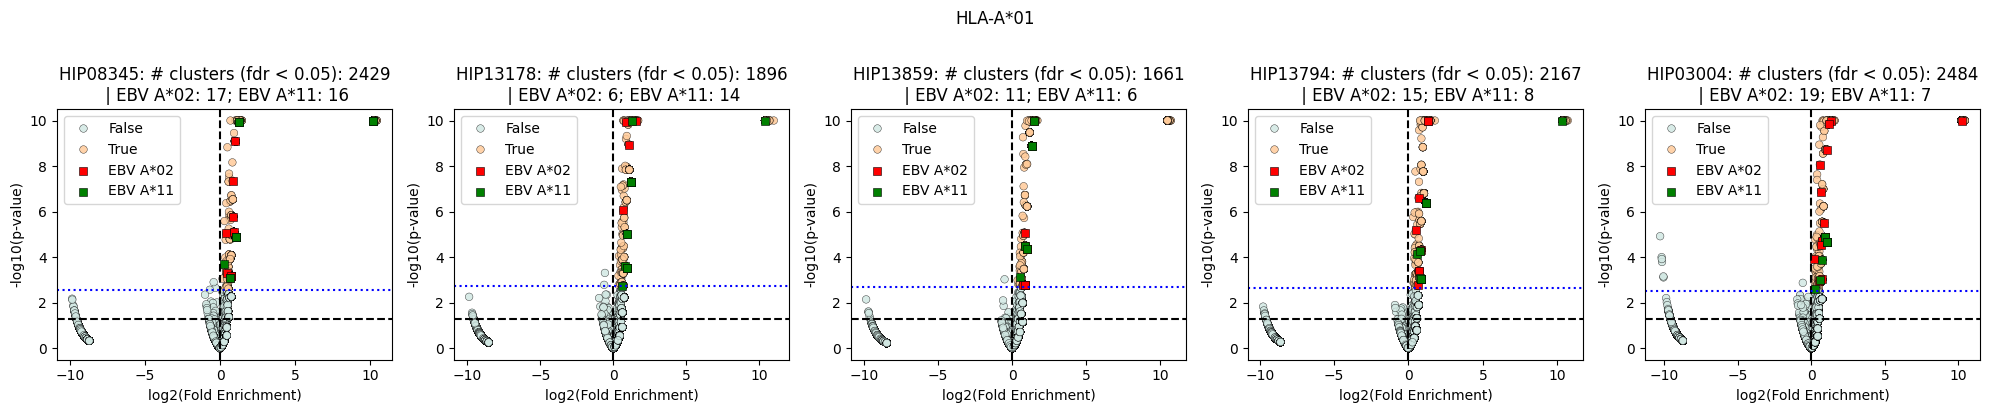

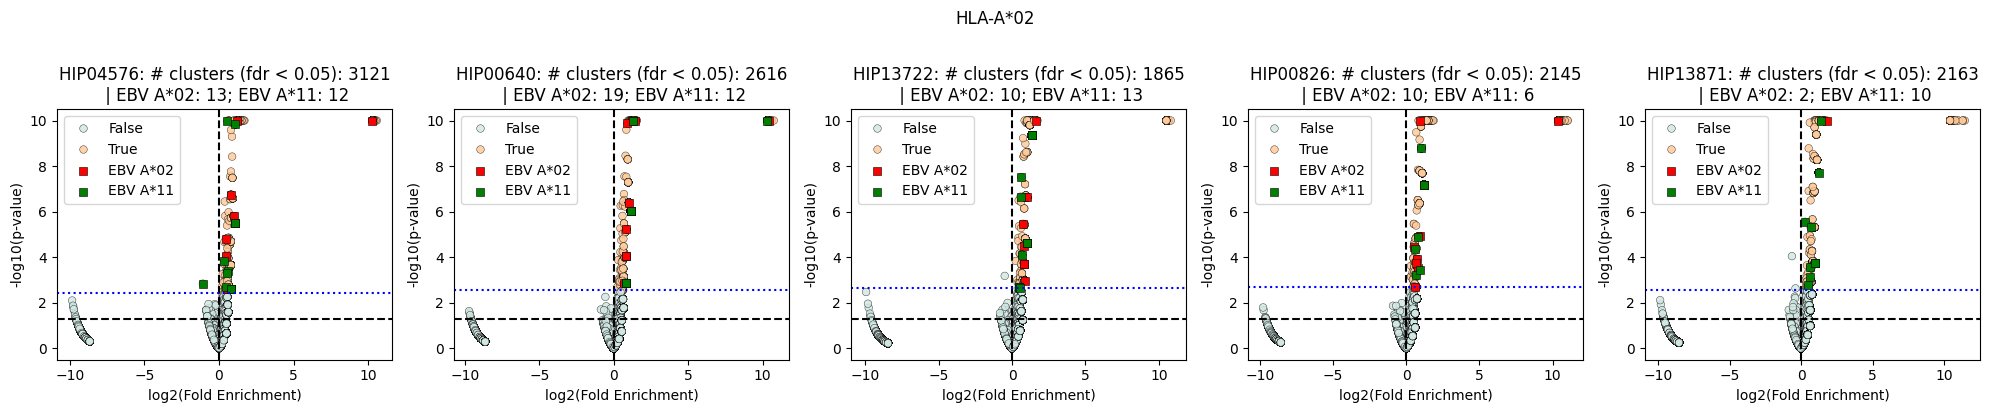

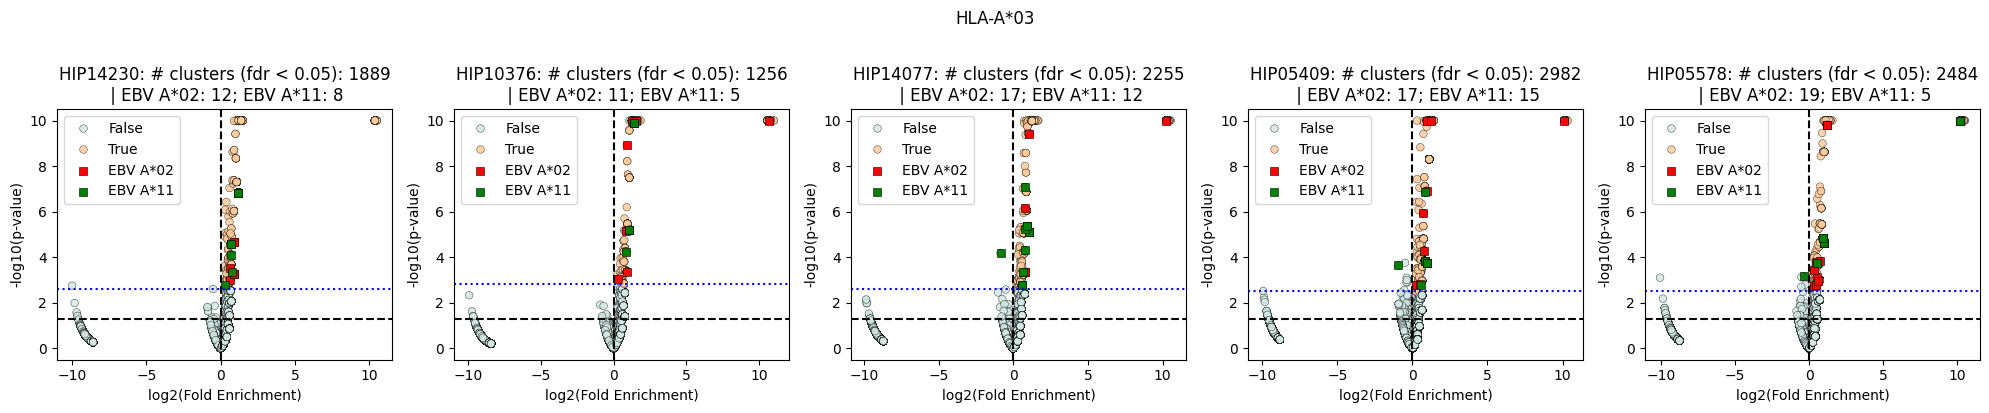

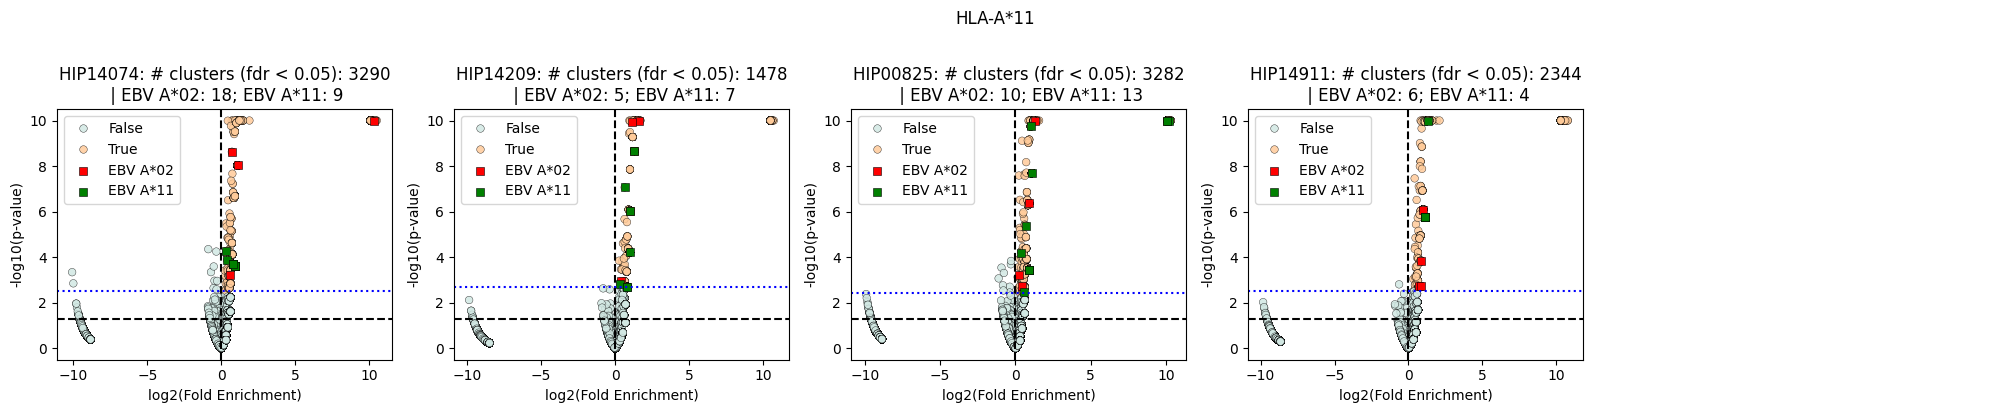

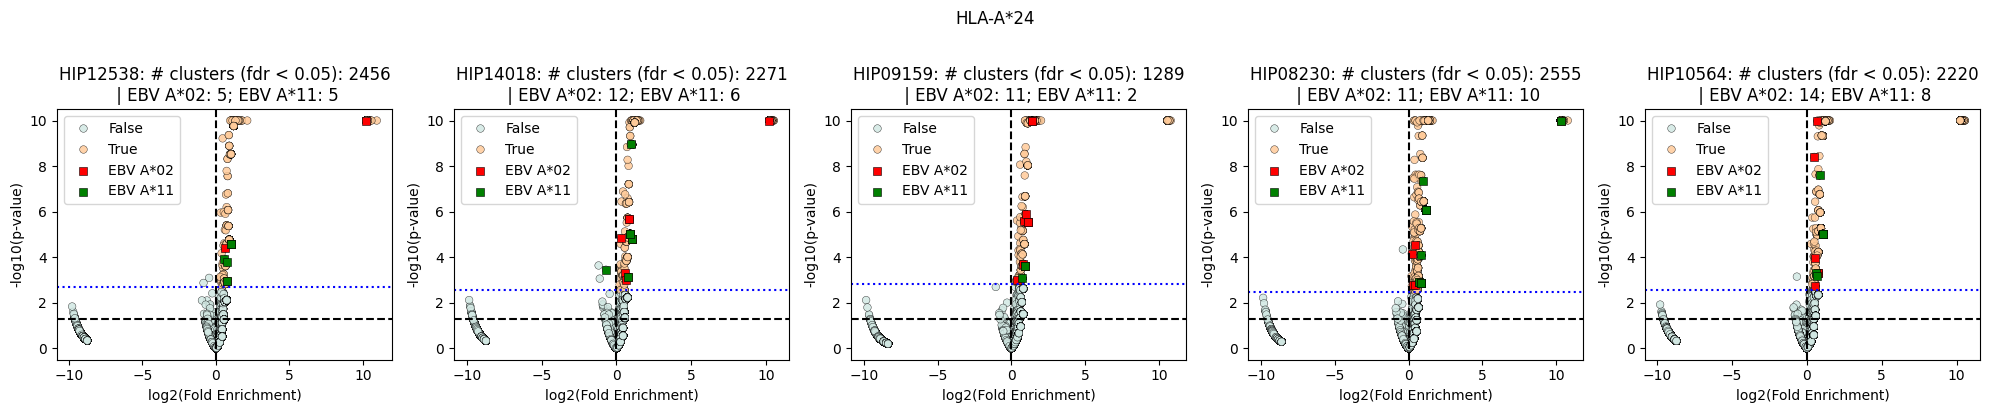

In [21]:
import numpy as np
import matplotlib.pyplot as plt

ncols = 5

for allele, res in allele_results.items():
    # список сэмплов (ровно те пять, что у этой аллели)
    cur_samples = allele_to_samples[allele]

    nrows = int(np.ceil(len(cur_samples) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), squeeze=False)
    fig.suptitle(f"{allele}", y=1.02)

    for i, s in enumerate(cur_samples):
        row, col = divmod(i, ncols)
        ax = axes[row, col]

        s_df = sample_to_info[s][0].copy()
        # s_df = s_df.merge(all_clusters_df)
        # Флаги для слоёв, TODO NEED TO CHANGE TO CHECK FOR ALL THE CLUSTERS???
        s_df["vdjdb_ebv_a02"] = s_df.cluster_id.apply(lambda x: utils.get_cluster_matches_vdjdb(
            sample_to_clonotypes[s], x, allele_to_vdjdb_subset['HLA-A*02']))
        s_df["vdjdb_ebv_a11"] = s_df.cluster_id.apply(lambda x: utils.get_cluster_matches_vdjdb(
            sample_to_clonotypes[s], x, allele_to_vdjdb_subset['HLA-A*11']))

        utils.plot_volcano(
            s_df,
            sample_name=s,
            ax=ax,
            layers=[
                {"col": "vdjdb_ebv_a02", "marker": "s", "color": "red",   "label": f"EBV A*02"},
                {"col": "vdjdb_ebv_a11", "marker": "s", "color": "green",   "label": f"EBV A*11"},
            ],
            layer_exclusive=False,
            point_size=30
        )

    # прячем пустые оси если сэмплов < nrows*ncols
    total_axes = nrows * ncols
    for j in range(len(cur_samples), total_axes):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

    
# попробовать сделать со стат значимостью -- хорошее покрытие кластера мотивом

In [22]:
s_df[s_df['vdjdb_ebv_a02']]

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change,vdjdb_ebv_a02,vdjdb_ebv_a11
17,17,30,14,16,9.044987e-12,9.309973e-10,0.709964,True,False
40,40,69,24,45,3.851592e-09,3.635584e-07,0.494954,True,False
911,911,3,2,1,9.478481e-06,1.999462e-04,1.068986,True,False
1264,1264,3,2,1,9.478481e-06,1.999462e-04,1.068986,True,False
2150,2150,3,2,1,9.478481e-06,1.999462e-04,1.068986,True,False
2234,2234,21,8,13,1.035222e-04,2.113050e-03,0.557102,True,False
4714,4714,6,3,3,5.057771e-04,9.619158e-03,0.767956,True,False
5045,5045,13,5,8,1.862842e-03,3.448404e-02,0.563836,True,False
6337,6337,6,3,3,5.057771e-04,9.619158e-03,0.767956,True,False
7945,7945,3,2,1,9.478481e-06,1.999462e-04,1.068986,True,False


In [23]:
allele_to_samples

{'HLA-A*01': ['HIP08345', 'HIP13178', 'HIP13859', 'HIP13794', 'HIP03004'],
 'HLA-A*02': ['HIP04576', 'HIP00640', 'HIP13722', 'HIP00826', 'HIP13871'],
 'HLA-A*03': ['HIP14230', 'HIP10376', 'HIP14077', 'HIP05409', 'HIP05578'],
 'HLA-A*11': ['HIP14074', 'HIP14209', 'HIP00825', 'HIP14911'],
 'HLA-A*24': ['HIP12538', 'HIP14018', 'HIP09159', 'HIP08230', 'HIP10564']}

In [24]:
sample_to_clonotypes['HIP08345']

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,pgen
0,s_0,16553,CASSVDSTGANVLTF,TRBV6-1*01,TRBJ2-6*01,sample,0.000013,4.665092e-09
1,s_210040,16553,CASSVESTGANVLNV,TRBV6-1*01,TRBJ2-6*01,sample,0.000013,0.000000e+00
2,b_198560,16553,CASSVDSSGANVLTF,TRBV6-1*01,TRBJ2-6*01,background,0.000013,5.795866e-08
3,s_4,0,CSARDPERGDTDTQYF,TRBV20-1*01,TRBJ2-3*01,sample,0.000013,1.021204e-10
4,s_111200,0,CSARDPERGDTDTKYL,TRBV20-1*01,TRBJ2-3*01,sample,0.000013,0.000000e+00
...,...,...,...,...,...,...,...,...
12344,s_231607,17391,CAAQGPSYEQYF,TRBV27*01,TRBJ2-7*01,sample,0.000013,3.798121e-09
12345,b_961301,17391,CASTGPSYEQYF,TRBV27*01,TRBJ2-7*01,background,0.000013,3.114460e-07
12346,s_232416,17421,CASSYSGFQETQYV,TRBV6-6*01,TRBJ2-5*01,sample,0.000013,4.041198e-17
12347,s_232417,17421,CASSYSGFQETQYF,TRBV6-6*01,TRBJ2-5*01,sample,0.000013,1.703326e-08


In [25]:
sample_to_info['HIP08345'][0]

,cluster_id,cluster_size,sample,background,enrichment_pvalue_zbinom,enrichment_fdr_zbinom,log_fold_change
0,0,3,2,1,0.000013,0.000261,1.056830
1,1,7,4,3,0.000002,0.000133,0.880738
2,2,3,1,2,0.273233,0.582960,0.454770
3,3,10,2,8,0.614789,0.691566,0.153740
4,4,40,7,33,0.615213,0.691968,0.082384
...,...,...,...,...,...,...,...
41961,41961,3,1,2,0.273233,0.582960,0.454770
41962,41962,3,0,3,0.468121,0.582960,-8.721322
41963,41963,3,0,3,0.468121,0.582960,-8.721322
41964,41964,3,0,3,0.468121,0.582960,-8.721322


In [26]:
sample_to_clonotypes['HIP08345'].merge(sample_to_info['HIP08345'][0])

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,pgen,cluster_size,sample,background,enrichment_fdr_zbinom,log_fold_change
0,s_0,16553,CASSVDSTGANVLTF,TRBV6-1*01,TRBJ2-6*01,sample,0.000013,4.665092e-09,3,2,1,0.000261,1.05683
1,s_210040,16553,CASSVESTGANVLNV,TRBV6-1*01,TRBJ2-6*01,sample,0.000013,0.000000e+00,3,2,1,0.000261,1.05683
2,b_198560,16553,CASSVDSSGANVLTF,TRBV6-1*01,TRBJ2-6*01,background,0.000013,5.795866e-08,3,2,1,0.000261,1.05683
3,s_4,0,CSARDPERGDTDTQYF,TRBV20-1*01,TRBJ2-3*01,sample,0.000013,1.021204e-10,3,2,1,0.000261,1.05683
4,s_111200,0,CSARDPERGDTDTKYL,TRBV20-1*01,TRBJ2-3*01,sample,0.000013,0.000000e+00,3,2,1,0.000261,1.05683
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12069,s_231607,17391,CAAQGPSYEQYF,TRBV27*01,TRBJ2-7*01,sample,0.000013,3.798121e-09,3,2,1,0.000261,1.05683
12070,b_961301,17391,CASTGPSYEQYF,TRBV27*01,TRBJ2-7*01,background,0.000013,3.114460e-07,3,2,1,0.000261,1.05683
12071,s_232416,17421,CASSYSGFQETQYV,TRBV6-6*01,TRBJ2-5*01,sample,0.000013,4.041198e-17,3,2,1,0.000261,1.05683
12072,s_232417,17421,CASSYSGFQETQYF,TRBV6-6*01,TRBJ2-5*01,sample,0.000013,1.703326e-08,3,2,1,0.000261,1.05683


In [27]:
cluster_summary_by_allele = {allele: df[['enrichment_pvalue_zbinom', 'cluster_size', 'sample', 'background', 'enrichment_fdr_zbinom', 'log_fold_change', 'merged_cluster_id']].drop_duplicates() for allele, df in common_by_allele.items()}


NameError: name 'common_by_allele' is not defined

In [29]:
import sys
sys.path.append('/mnt/data')  # где лежит tcrempnet_utils (1).py
import pandas as pd
import tcrempnet_utils as utils
from tcrempnet_utils import merge_clusters_by_shared_cdr3, compute_topsis_score

def pct_sample(source_col) -> float:
    return (source_col == 'sample').sum() / len(source_col)


# --- ВХОДНЫЕ ДАННЫЕ ---
# 1) словарь аллель -> список сэмплов этой аллели
#    Замените содержимое на ваш.
samples_by_allele = allele_to_samples


# --- ИМЕНА КОЛОНОК (если отличаются — поправьте здесь и ниже ничего менять не нужно) ---
sample_col  = "sample_name"
cluster_col = "cluster_id"
cdr3_col    = "cdr3aa_beta"
p_col       = "enrichment_pvalue_zbinom"
lfc_col     = "log_fold_change"

# --- СБОРКА df_in ПО КАЖДОЙ АЛЛЕЛИ ---
df_in_by_allele = {}

for allele, samples in samples_by_allele.items():
    frames = []
    for patient in samples:
        t = sample_to_clonotypes[patient].merge(sample_to_info[patient][0])  # оставляем pvalue, НЕ дропаем
        # нормализуем идентификатор кластера, добавляя префикс образца
        tt = t.copy()
        tt[cluster_col] = patient + '_c' + tt[cluster_col].astype(str)
        tt[sample_col] = patient
        # берем только необходимые колонки
        frames.append(tt)
        df_in_by_allele[allele] = pd.concat(frames, ignore_index=True)

# --- MERGE + TOPSIS ДЛЯ КАЖДОЙ АЛЛЕЛИ ---
ranked_by_allele = {}
merged_maps = {}         # при необходимости: карта старые cluster_id -> merged_cluster_id
common_by_allele = {}    # df с «общими» кластерами (встречаются >= 2 сэмплов)

for allele, df_in in df_in_by_allele.items():
    if df_in.empty:
        ranked_by_allele[allele] = df_in
        merged_maps[allele] = {}
        common_by_allele[allele] = df_in
        continue

    # 1) объединяем кластеры по общим CDR3
    dfm, cluster_map = merge_clusters_by_shared_cdr3(
        df_in,
        cluster_col=cluster_col,
        cdr3_col=cdr3_col,
        merged_col="merged_cluster_id"
    )
    merged_maps[allele] = cluster_map

    # 2) оставляем только кластеры, встречающиеся как минимум в двух разных образцах
    n_samp = (
        dfm.groupby("merged_cluster_id")[sample_col]
           .nunique()
           .rename("n_samples")
           .reset_index()
    )
    common_ids = set(n_samp.loc[n_samp["n_samples"] >= 2, "merged_cluster_id"])
    df_common = dfm[dfm["merged_cluster_id"].isin(common_ids)].copy()

    df_common["vdjdb_ebv_a02"] = df_common.cdr3aa_beta.apply(lambda x: utils.has_vdjdb_match(
        x, allele_to_vdjdb_subset['HLA-A*02']))
    df_common["vdjdb_ebv_a11"] = df_common.cdr3aa_beta.apply(lambda x: utils.has_vdjdb_match(
        x, allele_to_vdjdb_subset['HLA-A*11']))
    df_common = df_common.merge(df_in[['cluster_id', 'clone_id', 'pgen']])
    
    common_by_allele[allele] = df_common

    # 3) агрегация фич на уровне merged_cluster_id
    agg = (
        df_common.groupby("merged_cluster_id")
                 .agg(
                     n_samples=(sample_col, "nunique"),
                     pgen=('pgen', 'mean'),
                     cluster_size=(sample_col, 'count'), 
                     unique_cluster_size=('cdr3aa_beta', 'nunique'), 
                     sample_pct=('source', pct_sample),   # <-- процент sample
                     
                 )
                 .reset_index()
    )
    agg['log_cluster_size'] = np.log10(agg.cluster_size)
    agg['log_pgen'] = np.log10(agg.pgen)
    
    # 4) TOPSIS-ранжирование (pval — cost, lfc — benefit)
    metric_types = {'log_cluster_size': 'benefit', 
                    'n_samples': 'benefit', 
                    'log_pgen': 'cost', 
                    'sample_pct': 'benefit'}#, "lfc": "benefit"}
    ranked = compute_topsis_score(agg, metric_types)
    ranked_by_allele[allele] = ranked

# Результат:
# - df_in_by_allele[ALLELE] — исходный df_in по аллели
# - common_by_allele[ALLELE] — только «общие» кластеры по аллели
# - ranked_by_allele[ALLELE] — таблица с topsis_score, отсортированная по убыванию


In [30]:
ranked_by_allele['HLA-A*01']

,merged_cluster_id,n_samples,pgen,cluster_size,unique_cluster_size,sample_pct,log_cluster_size,log_pgen,topsis_score
0,325,5,5.894703e-08,331,246,0.283988,2.519828,-7.229538,0.589680
1,420,5,5.944922e-08,148,106,0.391892,2.170262,-7.225854,0.587195
2,297,5,2.077589e-07,268,139,0.361940,2.428135,-6.682440,0.576587
3,1953,5,1.392937e-07,105,62,0.466667,2.021189,-6.856068,0.573212
4,127,5,2.490517e-07,170,83,0.417647,2.230449,-6.603710,0.569296
...,...,...,...,...,...,...,...,...,...
809,1406,2,1.305613e-06,14,4,0.428571,1.146128,-5.884186,0.213811
810,5451,2,1.436340e-06,14,2,0.428571,1.146128,-5.842743,0.212543
811,3102,2,7.993412e-07,12,2,0.416667,1.079181,-6.097268,0.210773
812,4387,2,1.513817e-06,9,3,0.444444,0.954243,-5.819926,0.203149


In [31]:
x = common_by_allele['HLA-A*02']
x[x.merged_cluster_id == 5763]

,clone_id,cluster_id,cdr3aa_beta,v_beta,j_beta,source,enrichment_pvalue_zbinom,pgen,cluster_size,sample,background,enrichment_fdr_zbinom,log_fold_change,sample_name,merged_cluster_id,vdjdb_ebv_a02,vdjdb_ebv_a11
12690,s_88082,HIP13722_c9026,CASFFKQKTAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,0.0,1.712019e-14,6,6,0,0.0,10.812392,HIP13722,5763,0,0
12691,s_88083,HIP13722_c9026,CAIIFKEKTAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,0.0,1.082748e-14,6,6,0,0.0,10.812392,HIP13722,5763,0,0
12692,s_88084,HIP13722_c9026,CAIFFKQKTAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,0.0,1.420739e-15,6,6,0,0.0,10.812392,HIP13722,5763,0,0
12693,s_88085,HIP13722_c9026,CACFFKQKTAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,0.0,2.212126e-16,6,6,0,0.0,10.812392,HIP13722,5763,0,0
12694,s_88086,HIP13722_c9026,CAFFFKQKTAYEQYF,TRBV4-2*01,TRBJ2-7*01,sample,0.0,1.267691e-16,6,6,0,0.0,10.812392,HIP13722,5763,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20194,s_148932,HIP13871_c10116,CAFFFKQKTAYEQYF,TRBV24-1*01,TRBJ2-7*01,sample,0.0,1.267691e-16,32,32,0,0.0,11.452610,HIP13871,5763,0,0
20195,s_148933,HIP13871_c10116,CAFFFKQKTAYEQYF,TRBV24-1*01,TRBJ2-7*01,sample,0.0,1.267691e-16,32,32,0,0.0,11.452610,HIP13871,5763,0,0
20196,s_154626,HIP13871_c10116,CATIYKKKSAYEQYF,TRBV24-1*01,TRBJ2-7*01,sample,0.0,6.914380e-15,32,32,0,0.0,11.452610,HIP13871,5763,0,0
20197,s_154627,HIP13871_c10116,CATIYKQKSAYEQYF,TRBV24-1*01,TRBJ2-7*01,sample,0.0,7.761593e-15,32,32,0,0.0,11.452610,HIP13871,5763,0,0


In [32]:
from mir.basic.pgen import OlgaModel
from mir.basic.sampling import RepertoireSampling
from mir.basic.segment_usage import *
from mir.biomarkers.fisher_biomarkers_detector import FisherBiomarkersDetector
from mir.common.clonotype import ClonotypeAA
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.parser import *
from mir.common.repertoire import Repertoire
from mir.common.repertoire_dataset import RepertoireDataset
from mir.comparative.pair_matcher import ClonotypeRepresentation
from mir.comparative.pair_matcher import PairMatcher

In [33]:
meta

,sample_id,age,race,sex,cmv,hla,allele
0,HIP08345,,,male,-,"HLA-A*01,HLA-A*26,HLA-B*08,HLA-B*38",HLA-A*01
1,HIP13178,21.0,"caucasian,non-hispanic or latino",female,-,"HLA-A*01,HLA-B*14,HLA-B*37",HLA-A*01
2,HIP13859,51.0,"caucasian,non-hispanic or latino",male,-,"HLA-A*01,HLA-A*26,HLA-B*38,HLA-B*57",HLA-A*01
3,HIP13794,36.0,"caucasian,non-hispanic or latino",female,-,"HLA-A*01,HLA-A*32,HLA-B*57,HLA-B*62",HLA-A*01
4,HIP03004,42.0,,female,-,"HLA-A*01,HLA-A*25,HLA-B*08,HLA-B*44",HLA-A*01
5,HIP12538,24.0,"caucasian,non-hispanic or latino",male,-,"HLA-A*24,HLA-A*26,HLA-B*35,HLA-B*38",HLA-A*24
6,HIP14018,55.0,"caucasian,non-hispanic or latino",male,-,"HLA-A*24,HLA-B*15,HLA-B*40",HLA-A*24
7,HIP09159,36.0,,female,-,"HLA-A*24,HLA-A*32,HLA-B*44,HLA-B*62",HLA-A*24
8,HIP08230,35.0,,female,-,"HLA-A*24,HLA-A*29,HLA-B*44,HLA-B*62",HLA-A*24
9,HIP10564,45.0,"caucasian,non-hispanic or latino",female,-,"HLA-A*24,HLA-A*26,HLA-B*38,HLA-B*48",HLA-A*24


In [34]:
dataset = RepertoireDataset.load(parser=AIRRParser(), 
                                 metadata=meta,
                                 threads=16,
                                 paths=[f'/projects/immunestatus/emerson_hla/airr_format/{r}.tsv' for r in meta.sample_id], 
                                 gene='TRB')
dataset

loading Repertoire objects: 100%|██████████| 24/24 [00:35<00:00,  1.50s/it]


There are 24 repertoires in the dataset
  sample_id   age                              race     sex cmv  \
0  HIP08345                                            male   -   
1  HIP13178  21.0  caucasian,non-hispanic or latino  female   -   
2  HIP13859  51.0  caucasian,non-hispanic or latino    male   -   
3  HIP13794  36.0  caucasian,non-hispanic or latino  female   -   
4  HIP03004  42.0                                    female   -   

                                   hla    allele  \
0  HLA-A*01,HLA-A*26,HLA-B*08,HLA-B*38  HLA-A*01   
1           HLA-A*01,HLA-B*14,HLA-B*37  HLA-A*01   
2  HLA-A*01,HLA-A*26,HLA-B*38,HLA-B*57  HLA-A*01   
3  HLA-A*01,HLA-A*32,HLA-B*57,HLA-B*62  HLA-A*01   
4  HLA-A*01,HLA-A*25,HLA-B*08,HLA-B*44  HLA-A*01   

                                                path  
0  /projects/immunestatus/emerson_hla/airr_format...  
1  /projects/immunestatus/emerson_hla/airr_format...  
2  /projects/immunestatus/emerson_hla/airr_format...  
3  /projects/immunestatu

In [41]:
cd = ClonotypeDataset(dataset[0].clonotypes)

In [42]:
cds = [ClonotypeDataset(x.clonotypes) for x in dataset]

In [43]:
best_clusters = []
for hla, res in ranked_by_allele.items():
    cur =  res.head(5)
    cur['hla'] = hla
    best_clusters.append(cur)
final_df = pd.concat(best_clusters)

/scratch/ipykernel_53628/657189630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cur['hla'] = hla
/scratch/ipykernel_53628/657189630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cur['hla'] = hla
/scratch/ipykernel_53628/657189630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

In [45]:
cluster_to_usage = {}
for i, x in final_df.iterrows():
    current_clonotypes = common_by_allele[x.hla]
    current_clonotypes = current_clonotypes[current_clonotypes.merged_cluster_id == x.merged_cluster_id]
    usages = []
    for cd in cds:
        usages.append(len(cd.get_matching_clonotypes_for_set(clonotypes_of_interest=set(current_clonotypes.cdr3aa_beta),
                                           threshold=0)) / len(cd.clonotypes_cdr3aa))
    cluster_to_usage[x.hla[-2:] + '_' + str(x.merged_cluster_id)] = usages

In [46]:
usage_df = pd.DataFrame(cluster_to_usage)

NameError: name 'handles' is not defined

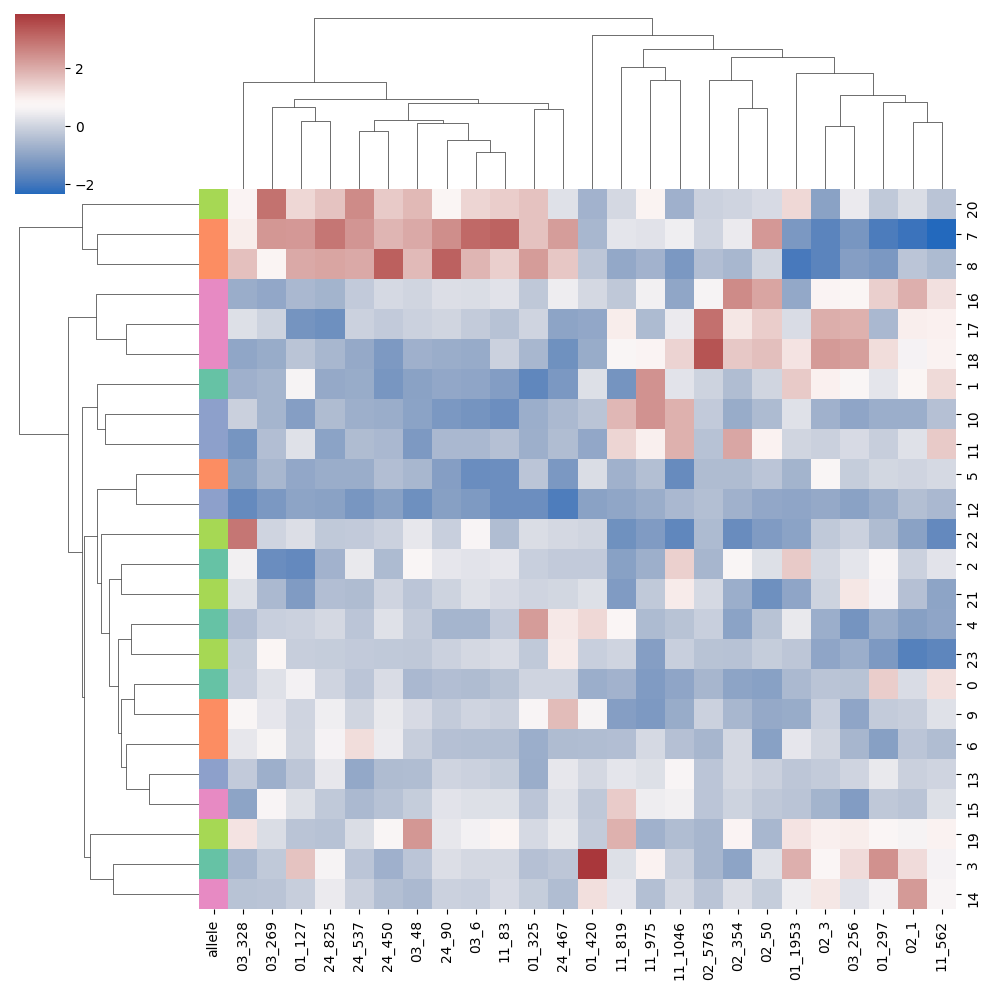

In [47]:
lut = dict(zip(meta.allele.unique(), sns.color_palette("Set2")))
row_colors = meta.allele.map(lut)
sns.clustermap(pd.DataFrame(StandardScaler().fit_transform(usage_df), columns=usage_df.columns), 
               row_colors=row_colors, cmap="vlag")
plt.legend(handles=handles, title="HLA", frameon=True, ncol=1)  # ncol — опционально
plt.show()
# plt.legend(lut)

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

handles = [mpatches.Patch(color=c, label=lab) for lab, c in lut.items()]

In [49]:
from sklearn.preprocessing import MinMaxScaler

Метрика: euclidean, Метод: average


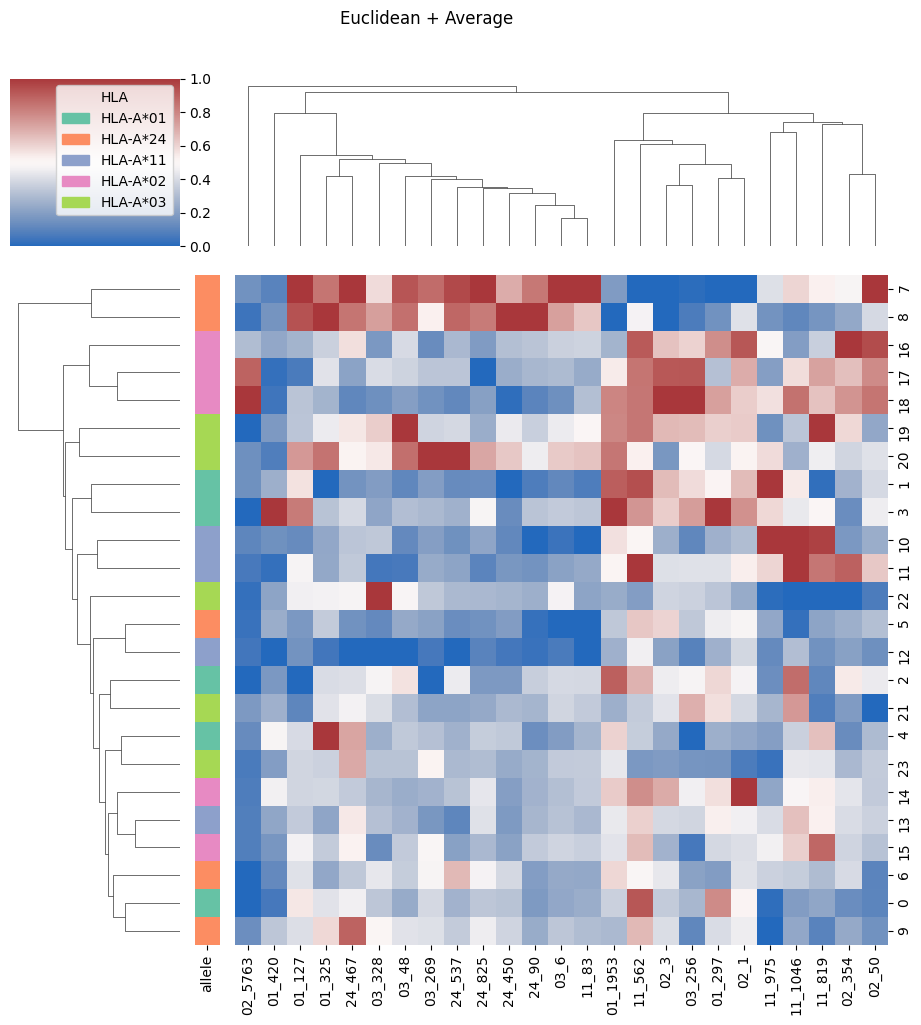

Метрика: euclidean, Метод: single


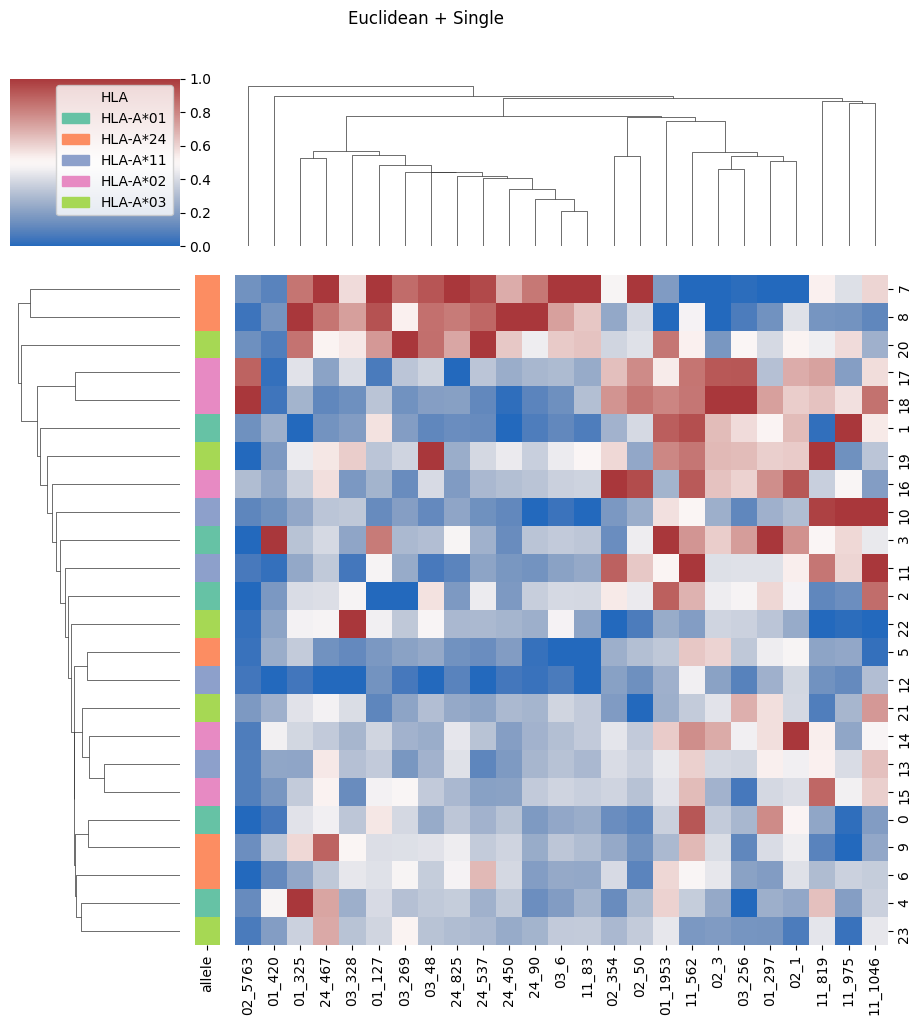

Метрика: euclidean, Метод: complete


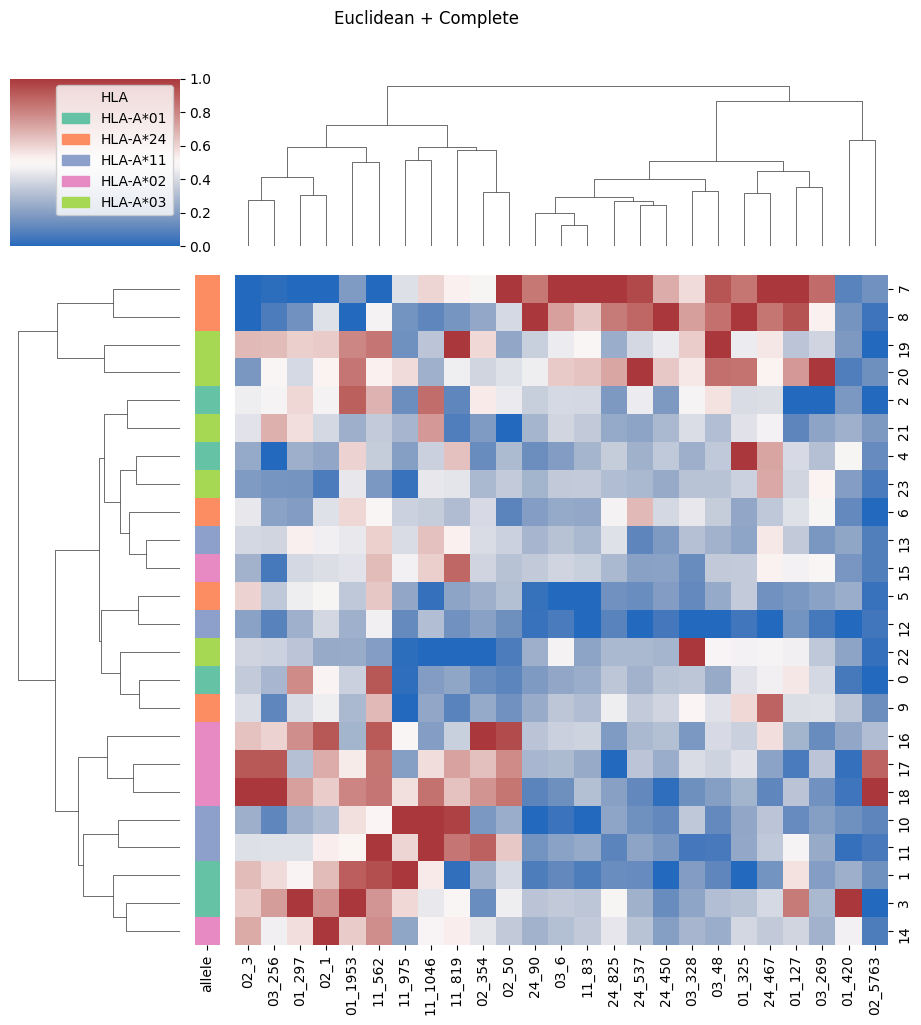

Метрика: euclidean, Метод: weighted


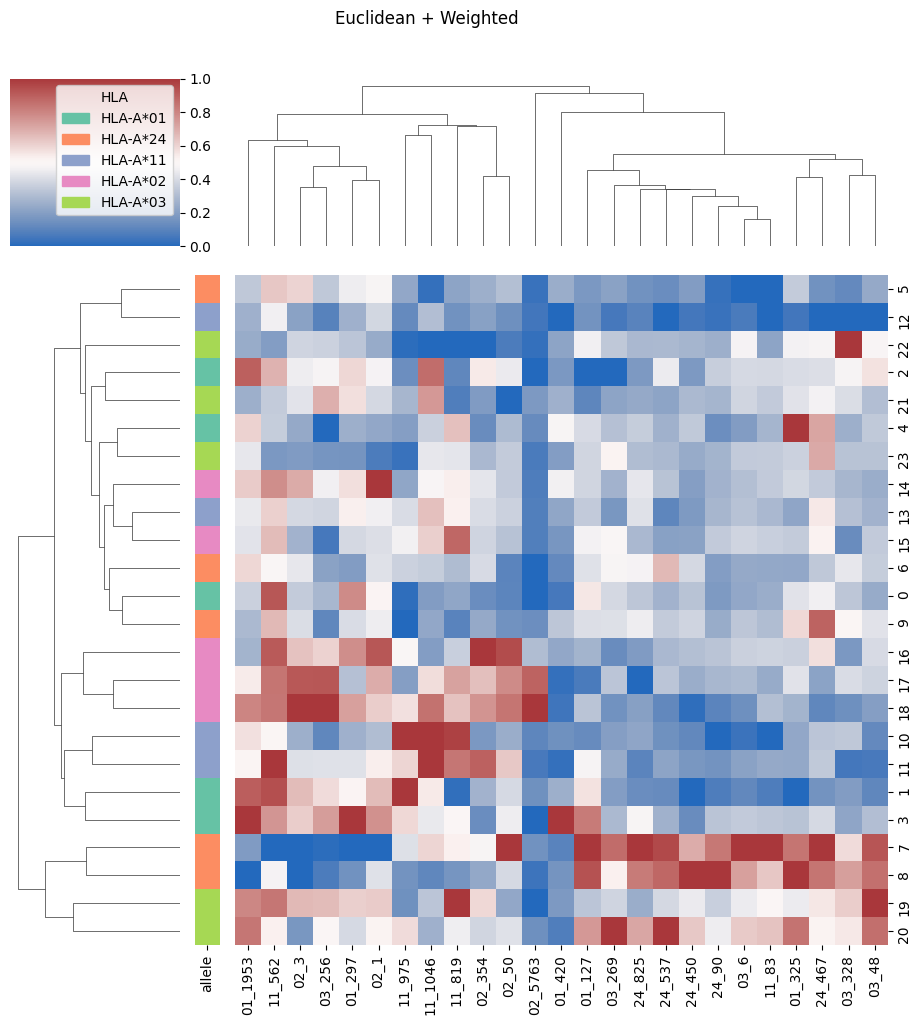

Метрика: euclidean, Метод: centroid


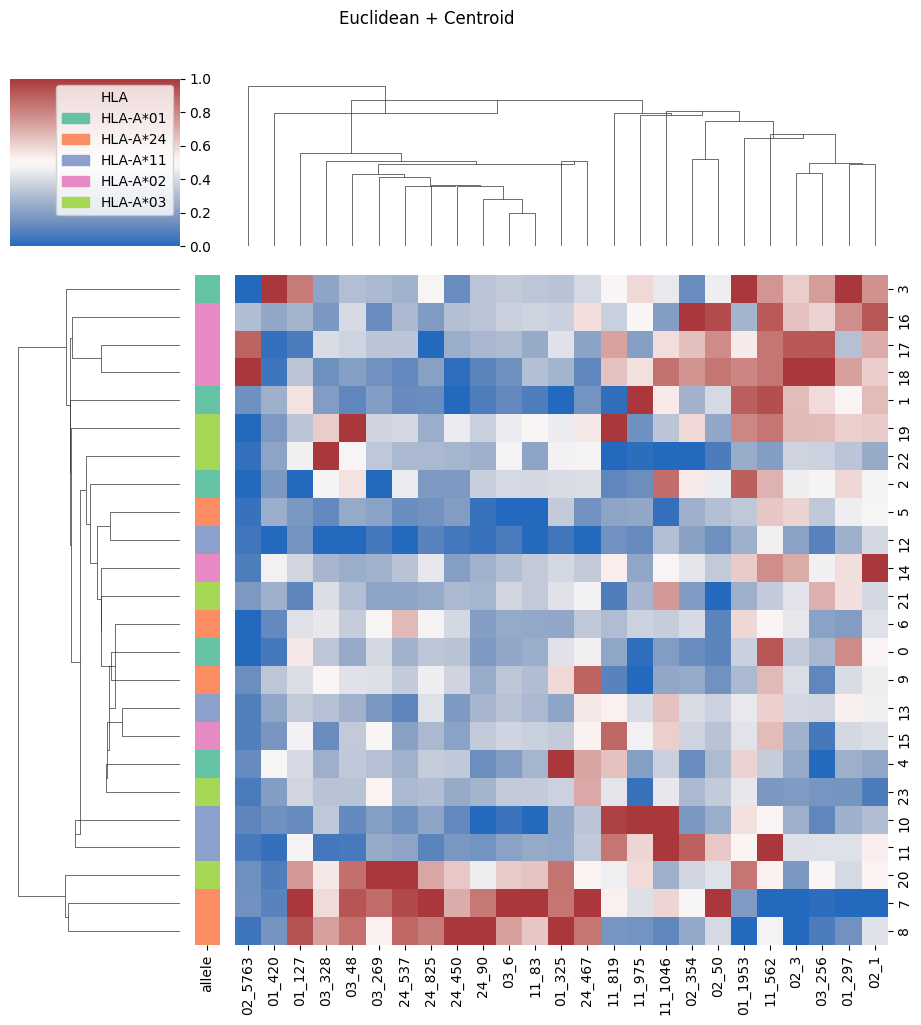

Метрика: cosine, Метод: average


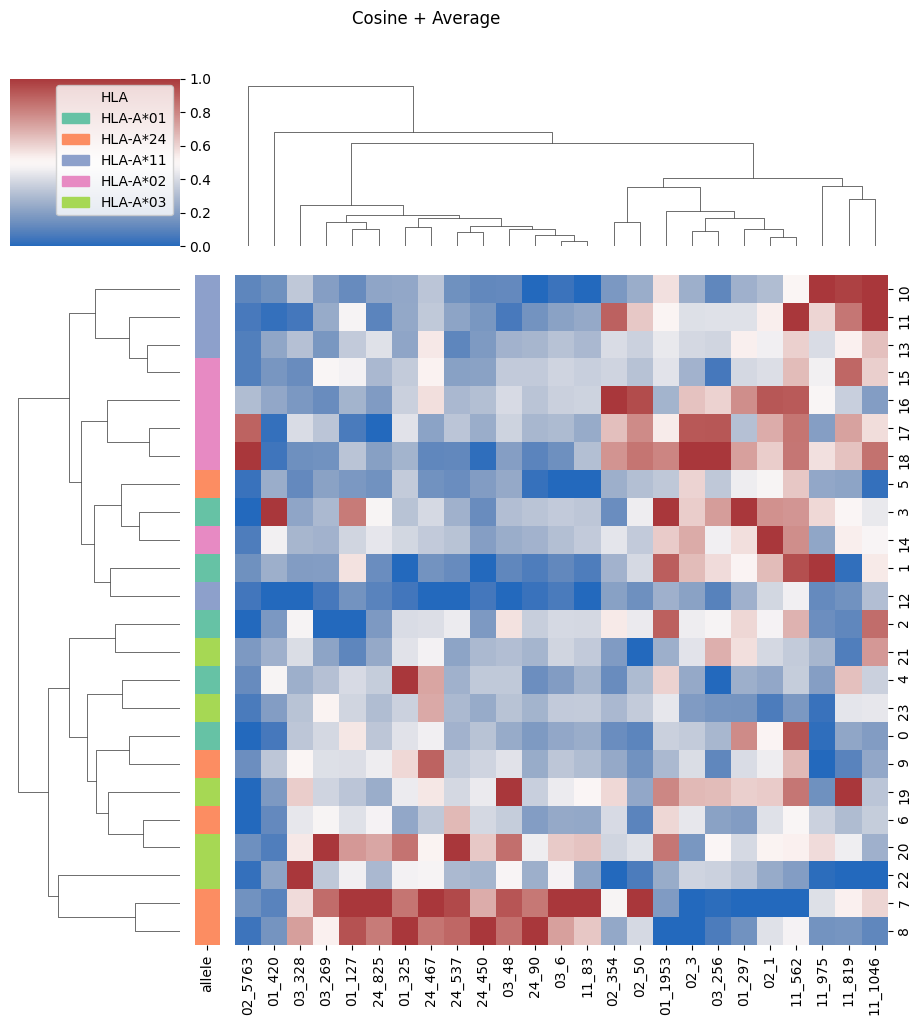

Метрика: cosine, Метод: single


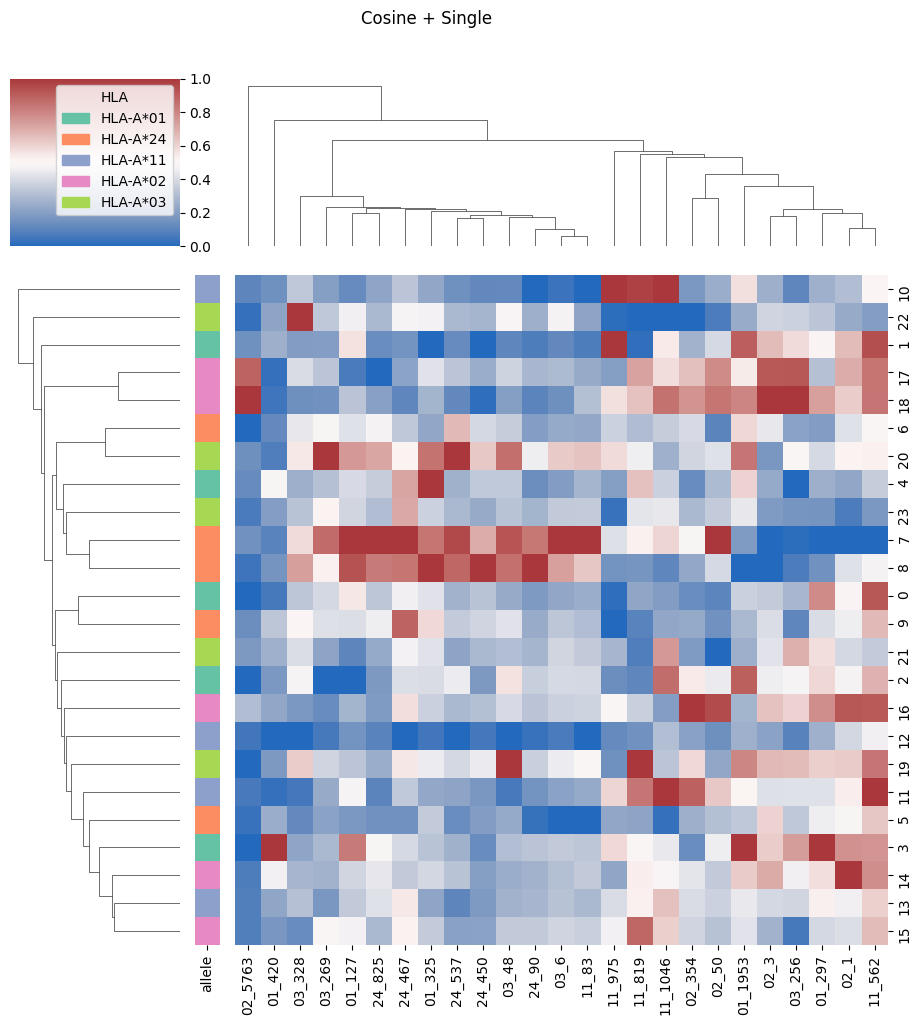

Метрика: cosine, Метод: complete


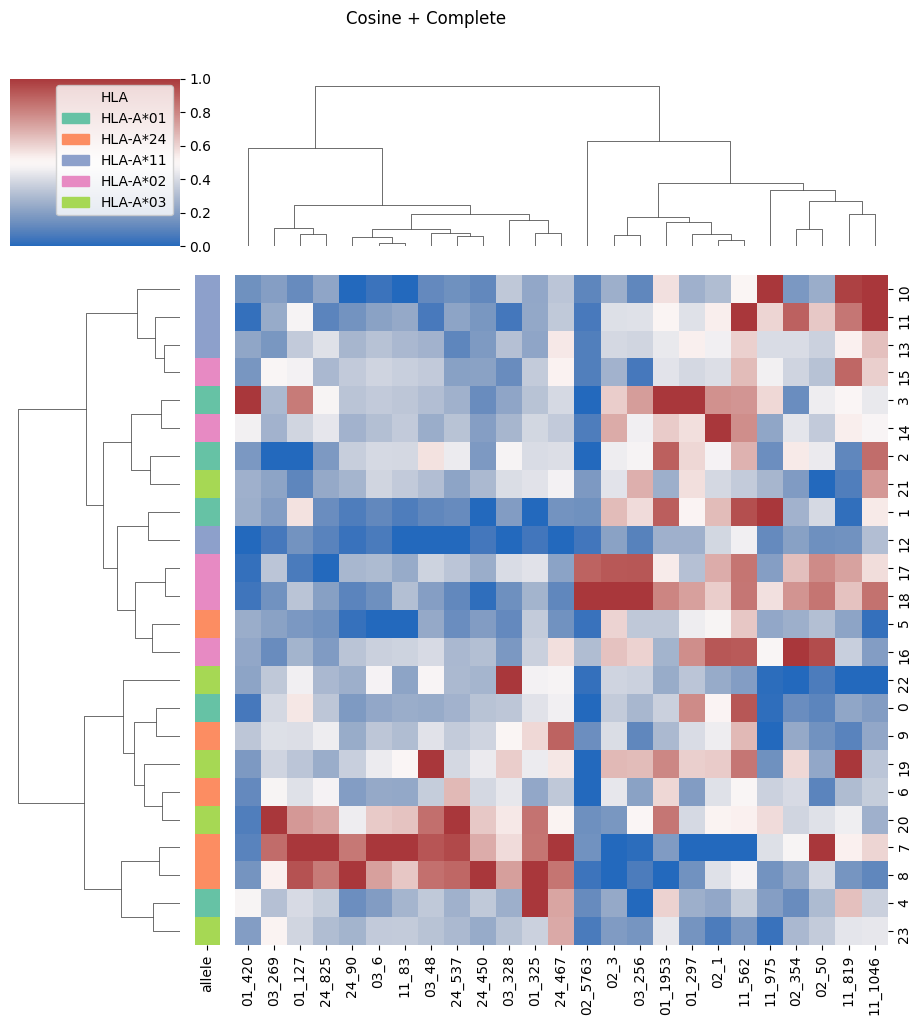

Метрика: cosine, Метод: weighted


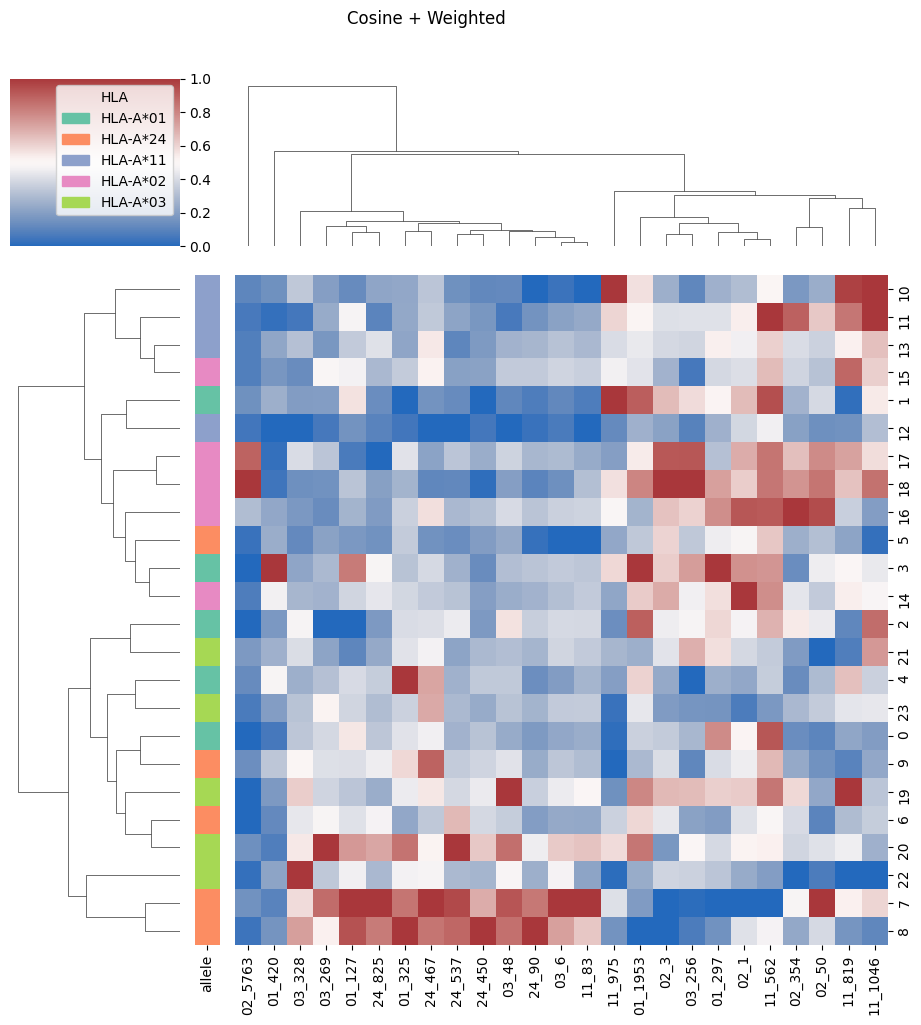

Метрика: cityblock, Метод: average


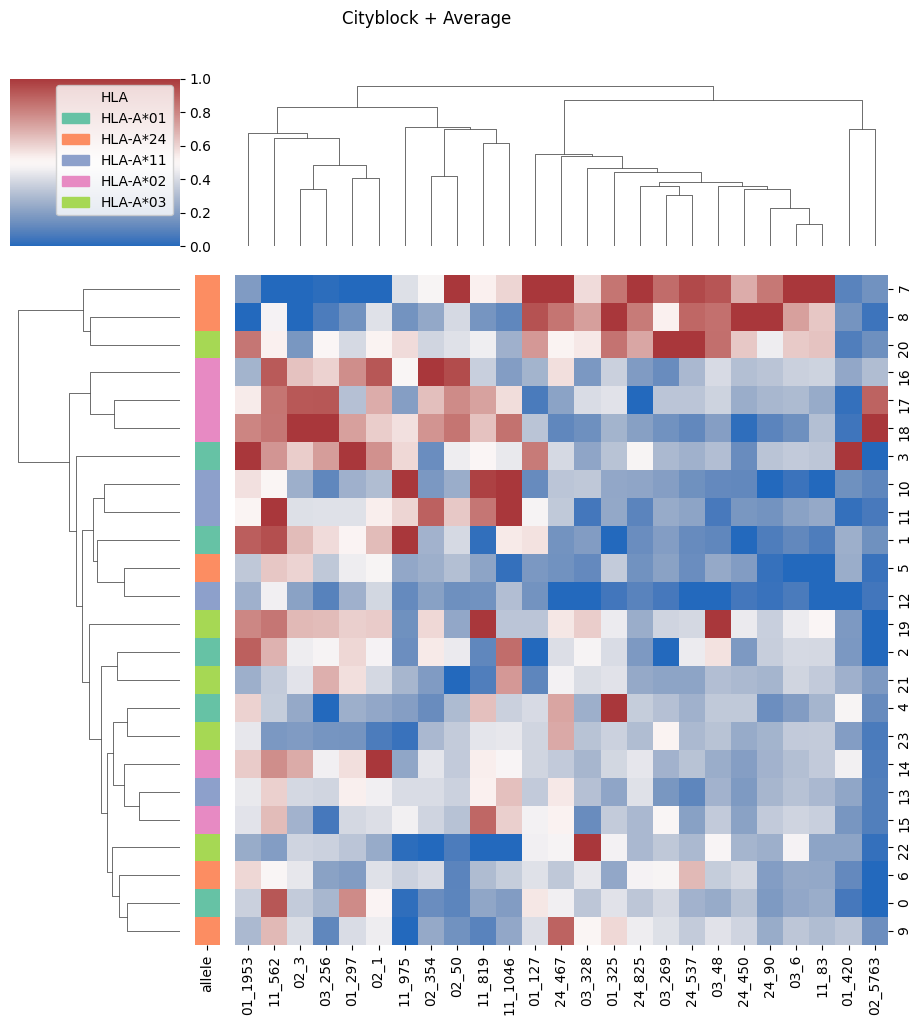

Метрика: cityblock, Метод: single


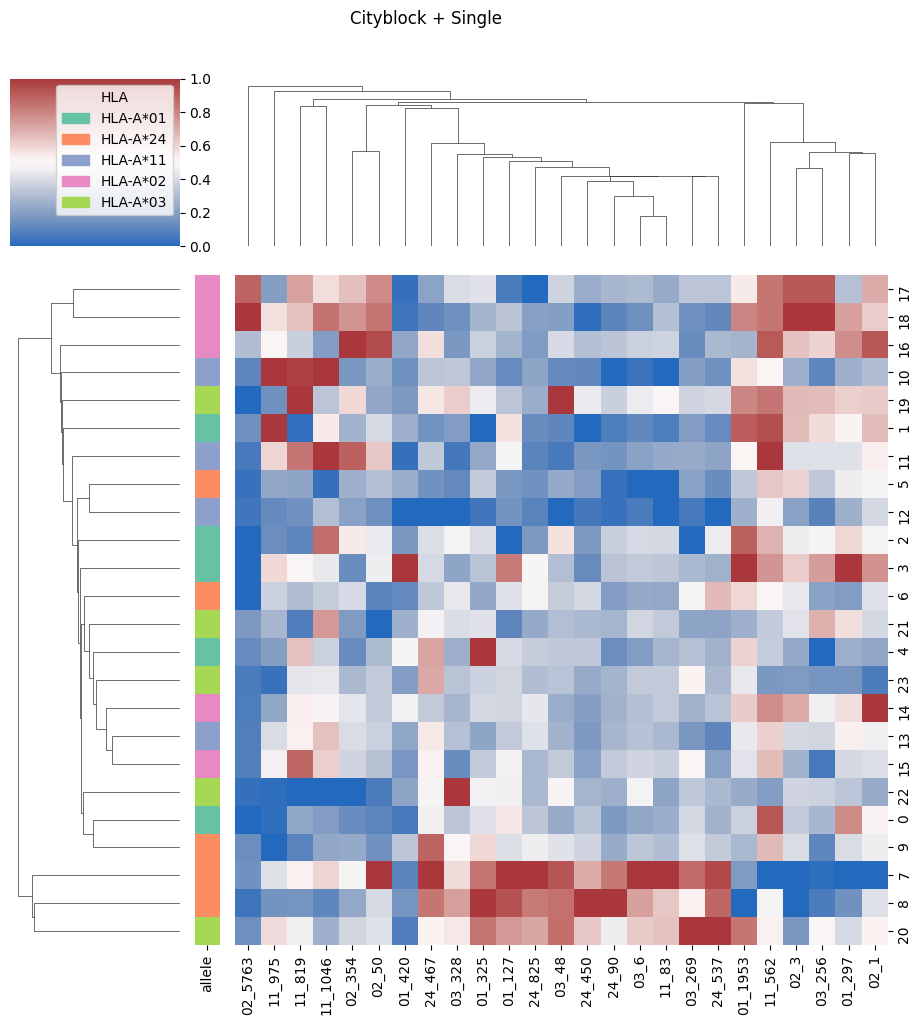

Метрика: cityblock, Метод: complete


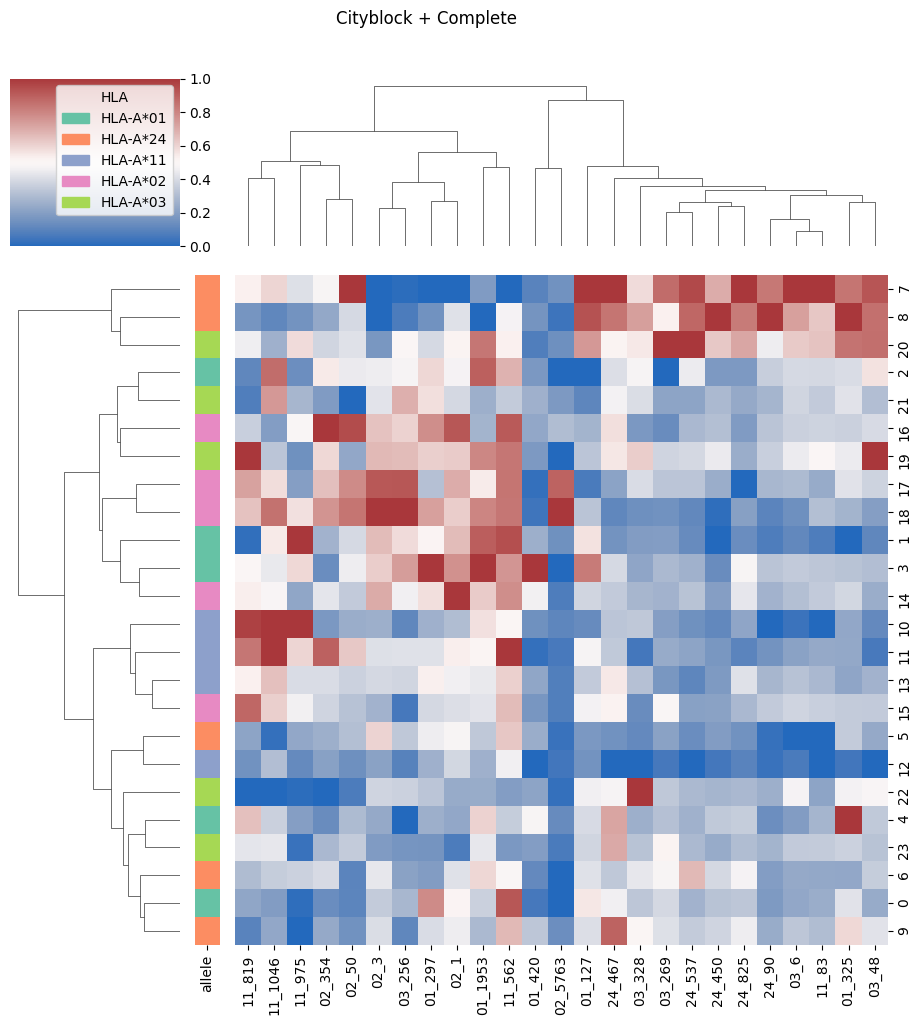

Метрика: cityblock, Метод: weighted


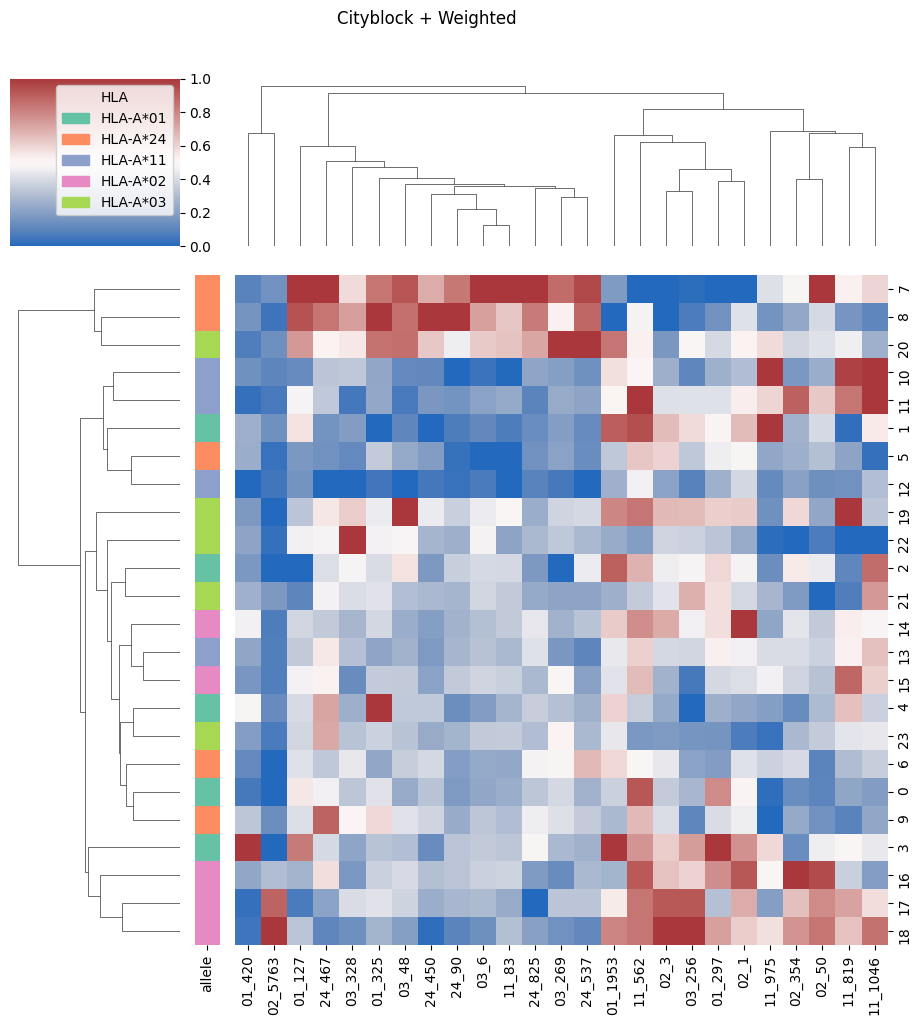

Метрика: correlation, Метод: average


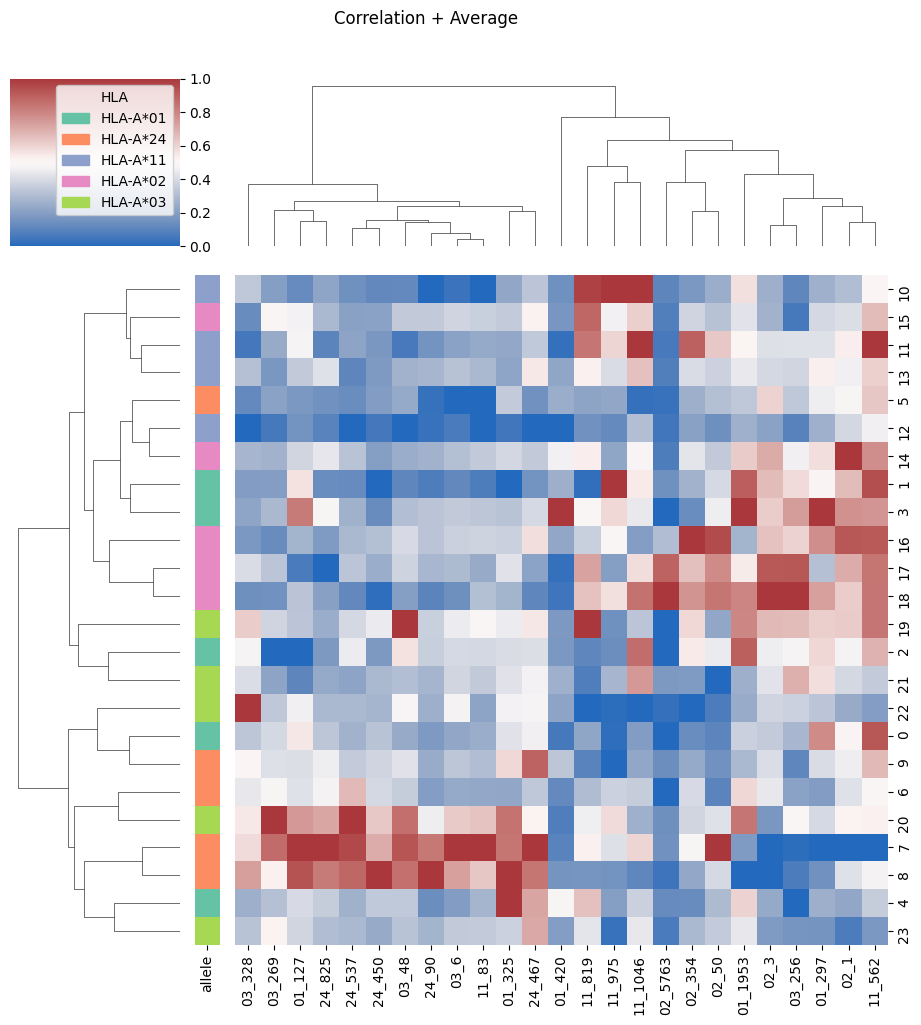

Метрика: correlation, Метод: single


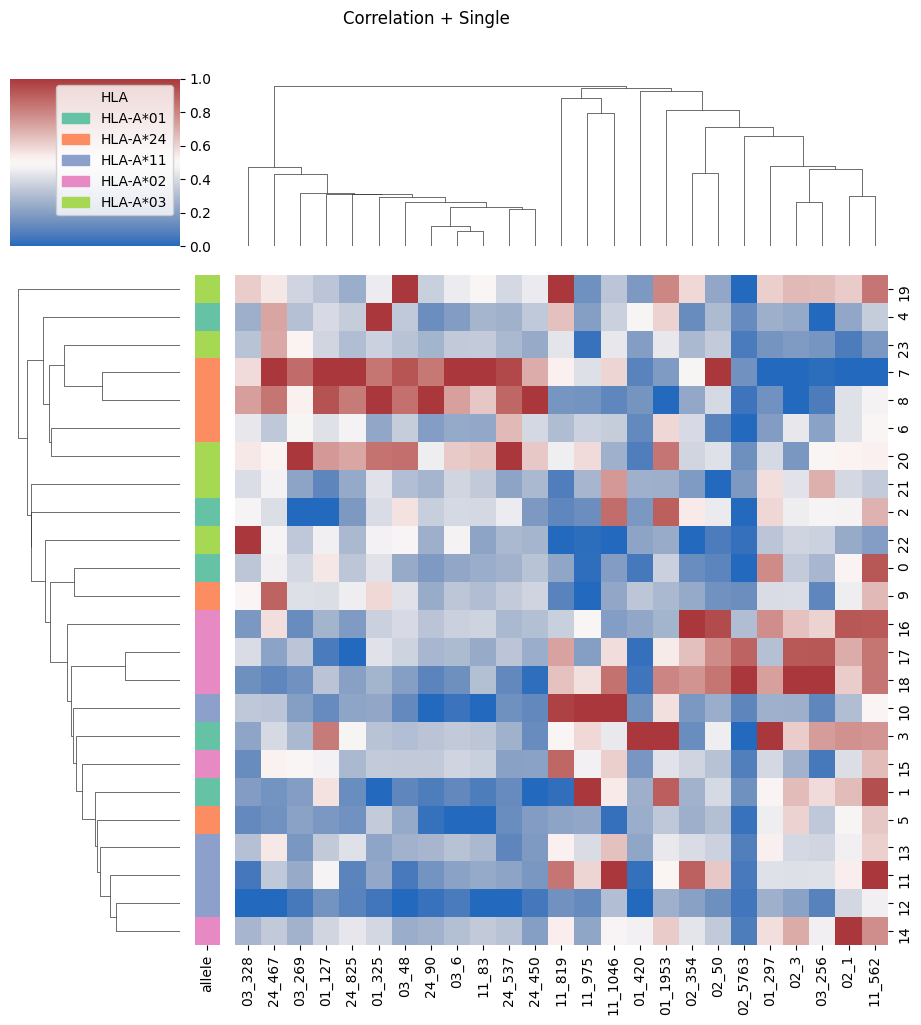

Метрика: correlation, Метод: complete


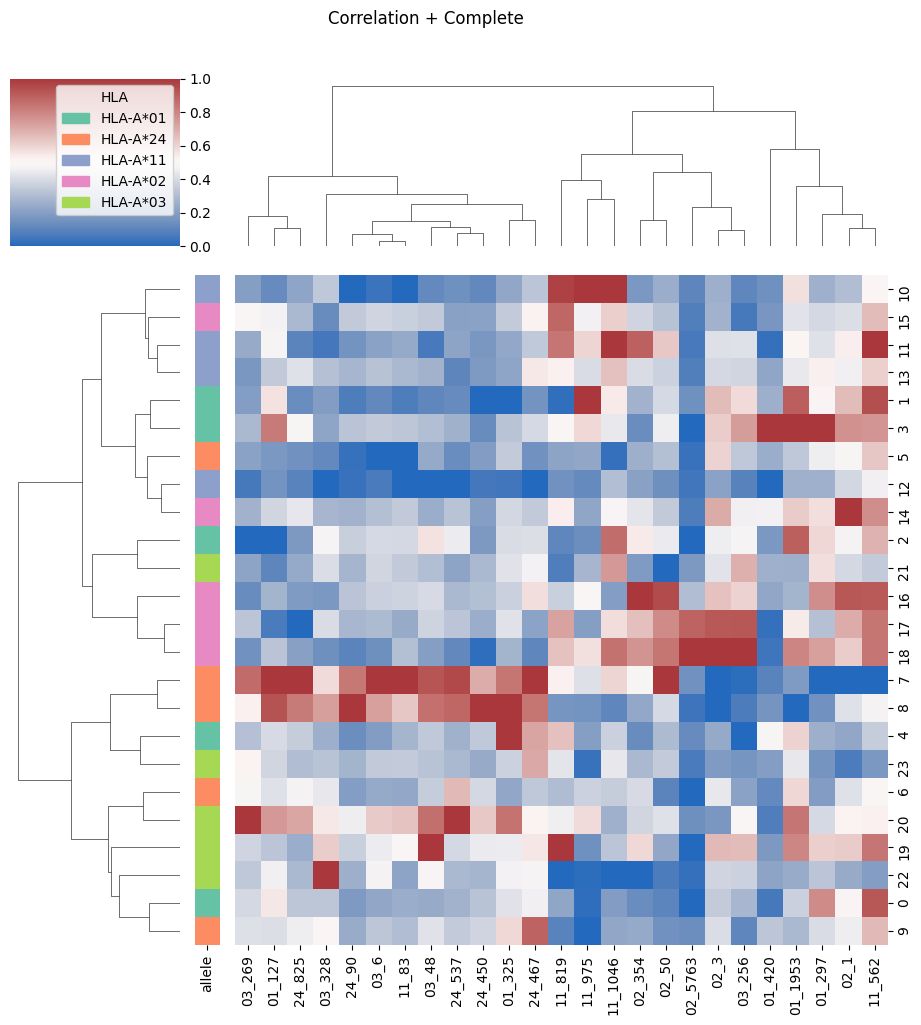

Метрика: correlation, Метод: weighted


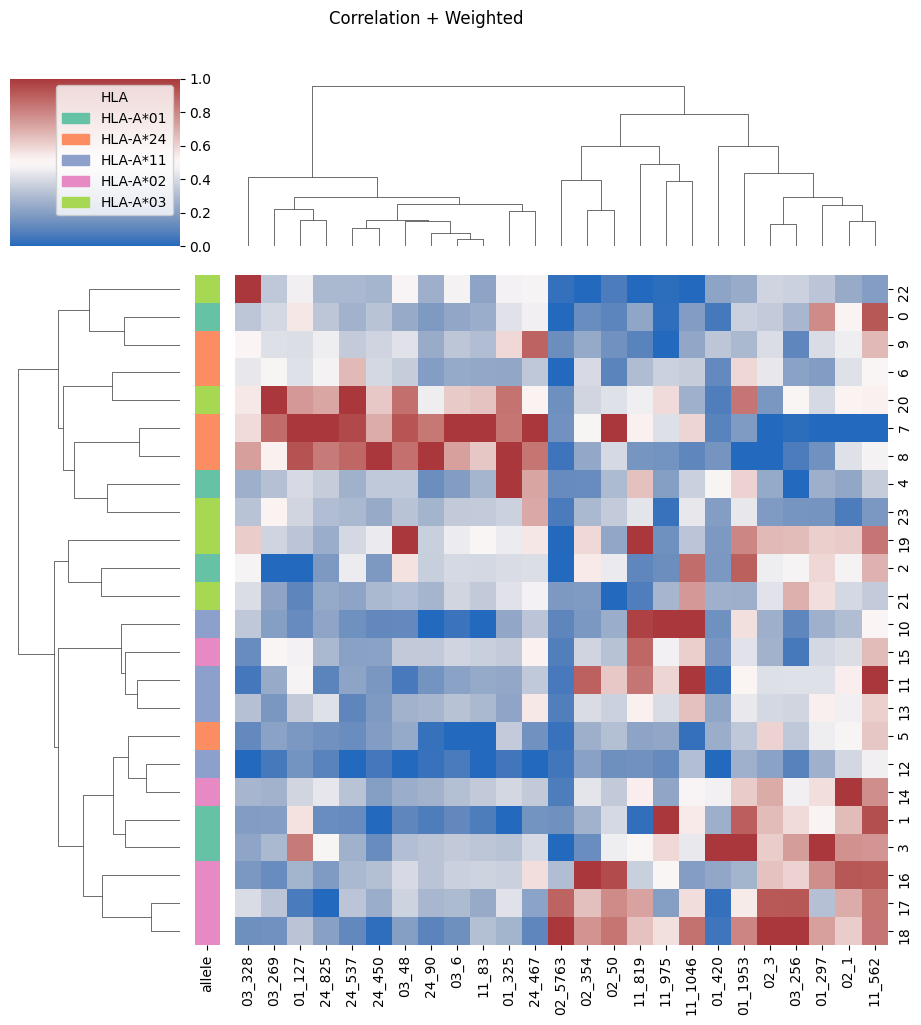

Метрика: chebyshev, Метод: average


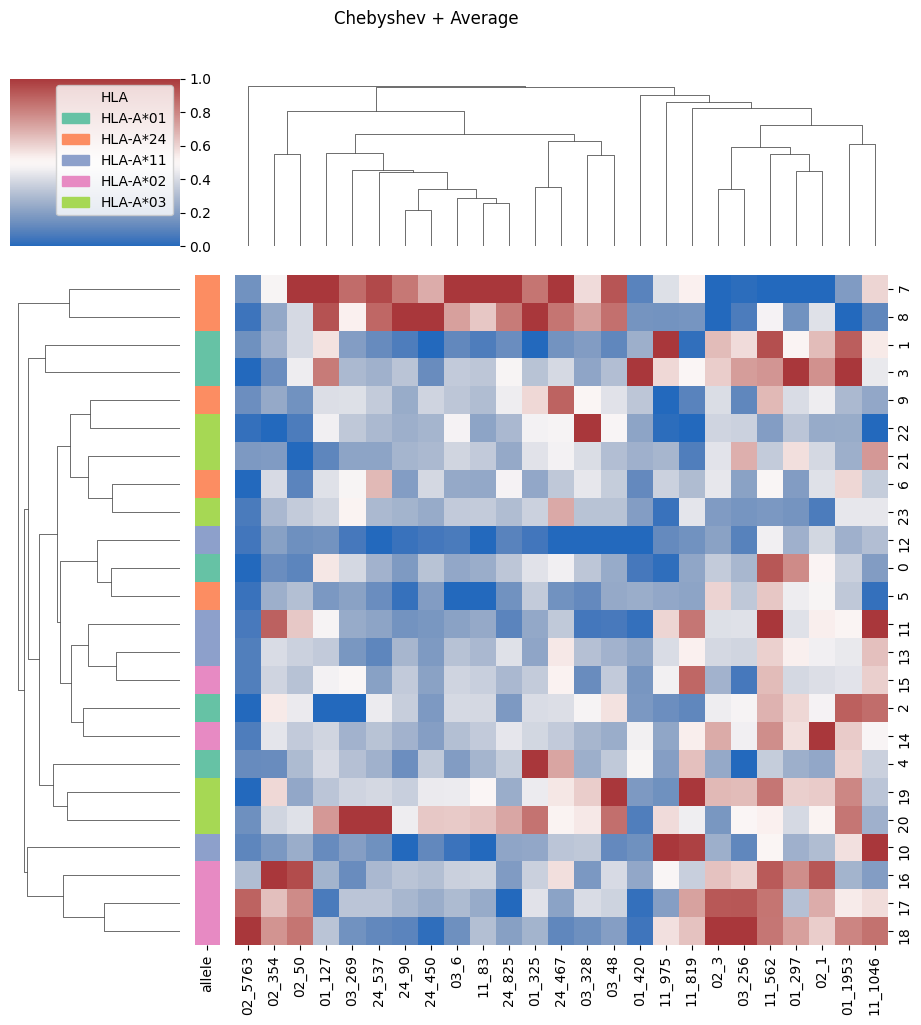

Метрика: chebyshev, Метод: single


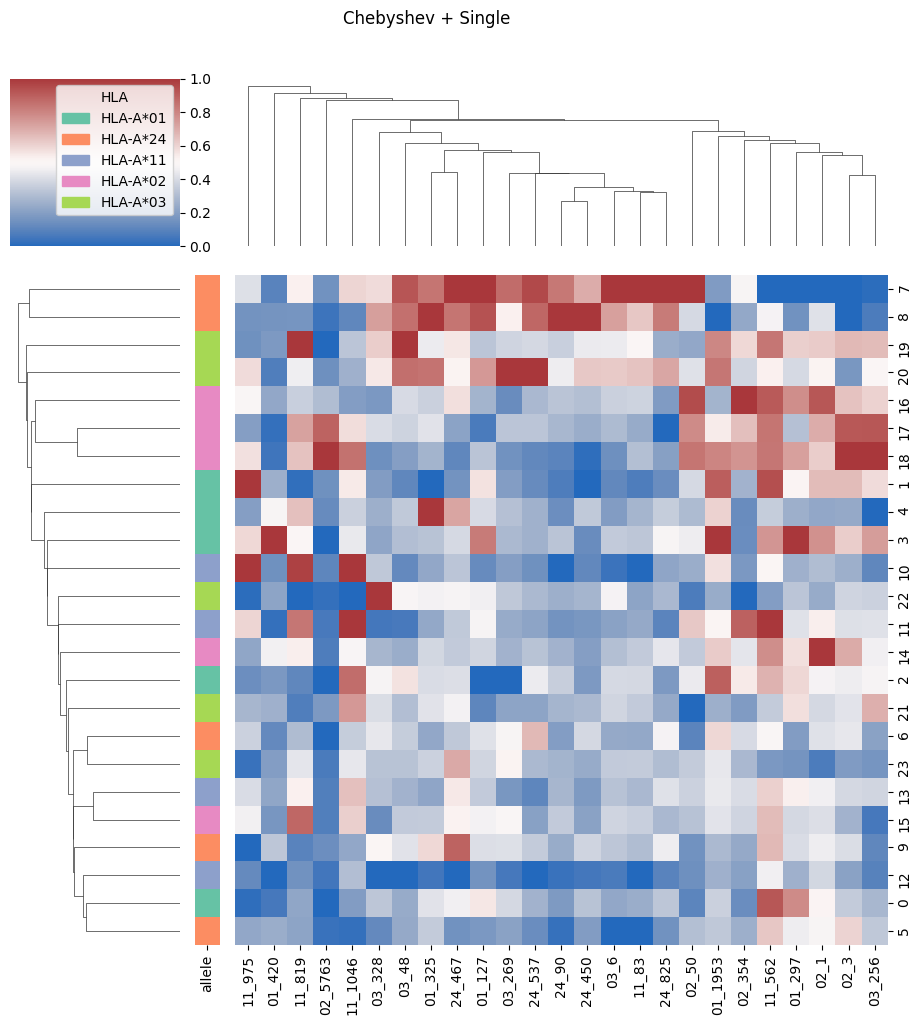

Метрика: chebyshev, Метод: complete


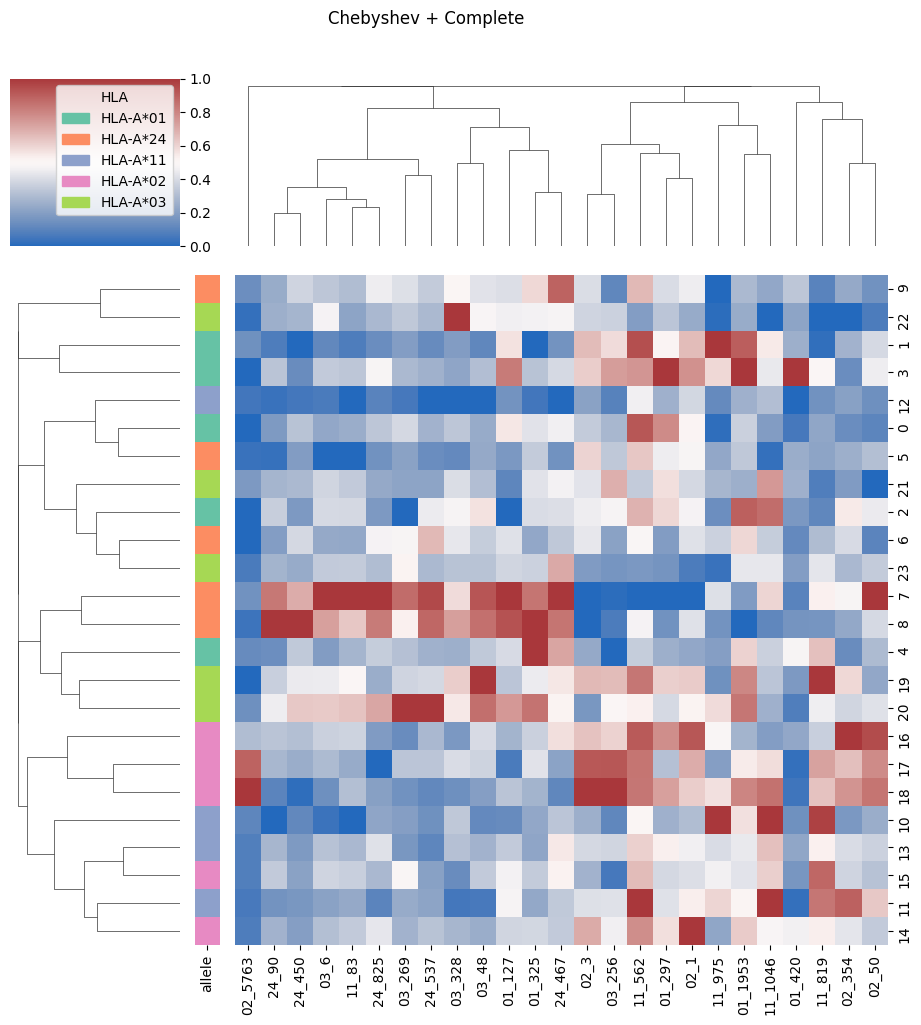

Метрика: chebyshev, Метод: weighted


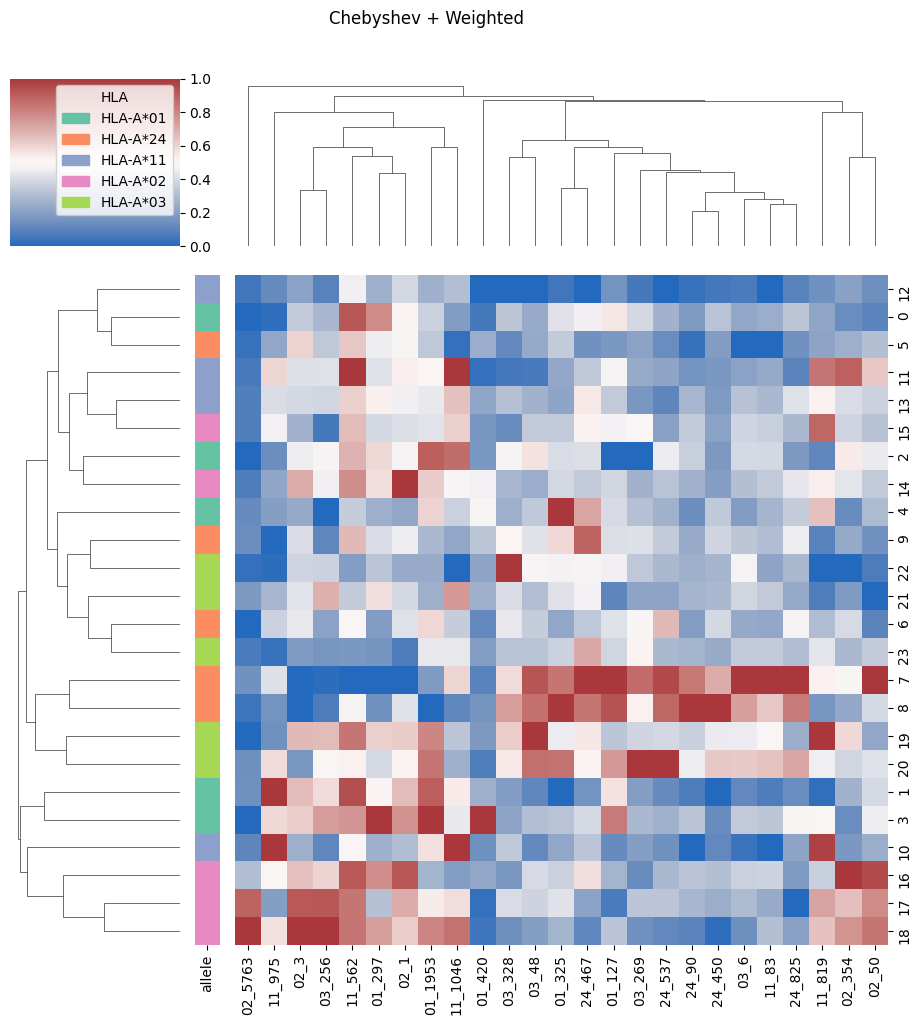

In [50]:
metrics = ['euclidean', 'cosine', 'cityblock', 'correlation', 'chebyshev']
methods = ['average', 'ward', 'single', 'complete', 'weighted', 'centroid']

for metric in metrics:
    for method in methods:
        # Ward требует евклидову метрику
        if method == 'ward' or method == 'centroid' and metric != 'euclidean':
            continue
        
        print(f"Метрика: {metric}, Метод: {method}")
        g = sns.clustermap(
            pd.DataFrame(MinMaxScaler().fit_transform(usage_df), columns=usage_df.columns), 
            row_colors=row_colors, 
            metric=metric,
            method=method,
            cmap="vlag")
        g.fig.suptitle(f'{metric.capitalize()} + {method.capitalize()}', y=1.02)
        plt.legend(handles=handles, title="HLA", frameon=True, ncol=1)  # ncol — опционально
        plt.tight_layout()
        plt.show()